# ML Experiment Results Analysis & Visualization
## Invoice Payment Prediction — April 2026 Corrected Re-run

**Source DB:** `results/2026_04_25_01/results.db`  
**Experiments:** 1092 total (15 models × 7 balance strategies × ~10 param sets × 2 feature phases)  
**Primary metrics:** `enhanced_f1_macro`, `enhanced_roc_auc_macro`  
**Output figures:** `data/results_graphics/RG_2026_04_18_02/`

---
All four pipeline bugs (resample accumulation, Cox leakage, pickling, nested parallelism) were fixed before this run. Schema v3 — `undersample_threshold` fully populated for all hybrid rows.

In [1]:
from pathlib import Path
import sys
import os

# Automatically find repo root by looking for .git
ROOT = Path.cwd()
while not (ROOT / ".git").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

os.chdir(ROOT)

print(f"Current root: {ROOT}")

Current root: c:\Users\rjbel\Python\Notebooks\Mapua\Thesis


In [2]:
# pyright: reportUnusedImport=false, reportUnusedVariable=false
import sqlite3
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

from src.modules.machine_learning.utils.io.load_results_from_folder import SessionStore

warnings.filterwarnings("ignore")

# ── Load session via SessionStore ─────────────────────────────────────────────
store = SessionStore("data/training_results/")
session_name = store.list()[0]  # most recent

DB_PATH = store.path()
repo = store.repository()

# Extract date and version from directory name (format: YYYY_MM_DD_VV)
parts = session_name.split('_')
if len(parts) >= 4:
    date_str = f"{parts[0]}_{parts[1]}_{parts[2]}"
    version_str = parts[3]
    output_folder_name = f"RG_{date_str}_{version_str}"
else:
    output_folder_name = f"RG_{session_name}"

OUTPUT_DIR = Path("data/results_graphics") / output_folder_name
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "serif",
    "font.size":        10,
    "axes.titlesize":   12,
    "axes.labelsize":   10,
    "xtick.labelsize":  9,
    "ytick.labelsize":  9,
    "legend.fontsize":  9,
    "figure.dpi":       120,
    "savefig.dpi":      300,
    "savefig.bbox":     "tight",
    "axes.spines.top":  False,
    "axes.spines.right": False,
})

# ── Model metadata ────────────────────────────────────────────────────────────
BASE_MODELS    = ["ada_boost", "decision_tree", "gaussian_naive_bayes",
                  "knn", "random_forest", "xgboost"]
ORDINAL_MODELS = ["ordinal_ada_boost", "ordinal_random_forest", "ordinal_xgboost"]
TWO_STAGE_MODELS = ["two_stage_ada_xgb", "two_stage_rf_ada", "two_stage_rf_rf",
                    "two_stage_xgb_ada", "two_stage_xgb_rf", "two_stage_xgb_xgb"]
ALL_MODELS = BASE_MODELS + ORDINAL_MODELS + TWO_STAGE_MODELS

MODEL_DISPLAY = {
    "ada_boost":            "AdaBoost",
    "decision_tree":        "Decision Tree",
    "gaussian_naive_bayes": "Gaussian NB",
    "knn":                  "KNN",
    "random_forest":        "Random Forest",
    "xgboost":              "XGBoost",
    "ordinal_ada_boost":    "Ordinal AdaBoost",
    "ordinal_random_forest":"Ordinal RF",
    "ordinal_xgboost":      "Ordinal XGBoost",
    "two_stage_ada_xgb":    "TS Ada→XGB",
    "two_stage_rf_ada":     "TS RF→Ada",
    "two_stage_rf_rf":      "TS RF→RF",
    "two_stage_xgb_ada":    "TS XGB→Ada",
    "two_stage_xgb_rf":     "TS XGB→RF",
    "two_stage_xgb_xgb":    "TS XGB→XGB",
}

FAMILY_MAP = {}
FAMILY_MAP.update({m: "Base"      for m in BASE_MODELS})
FAMILY_MAP.update({m: "Ordinal"   for m in ORDINAL_MODELS})
FAMILY_MAP.update({m: "Two-Stage" for m in TWO_STAGE_MODELS})

ORDINAL_BASE_MAP = {
    "ordinal_ada_boost":    "ada_boost",
    "ordinal_random_forest":"random_forest",
    "ordinal_xgboost":      "xgboost",
}
TWO_STAGE_BASE_MAP = {
    "two_stage_ada_xgb": "xgboost",
    "two_stage_rf_ada":  "ada_boost",
    "two_stage_rf_rf":   "random_forest",
    "two_stage_xgb_ada": "ada_boost",
    "two_stage_xgb_rf":  "random_forest",
    "two_stage_xgb_xgb": "xgboost",
}

STRATEGY_ORDER = ["none", "smote", "borderline_smote", "smote_tomek",
                  "hybrid@0.5", "hybrid@0.7", "hybrid@0.9"]
STRATEGY_LABELS = {
    "none":             "None",
    "smote":            "SMOTE",
    "borderline_smote": "Borderline SMOTE",
    "smote_tomek":      "SMOTE+Tomek",
    "hybrid@0.5":       "Hybrid @0.5",
    "hybrid@0.7":       "Hybrid @0.7",
    "hybrid@0.9":       "Hybrid @0.9",
}

CLASS_NAMES = ["On-Time (0)", "30-Day (1)", "60-Day (2)", "90-Day (3)"]

FAMILY_PALETTE = {"Base": "#4878CF", "Ordinal": "#6ACC65", "Two-Stage": "#D65F5F"}
STRATEGY_PALETTE = dict(zip(STRATEGY_ORDER, sns.color_palette("tab10", 7)))

print("✓ Configuration loaded")
print(f"  Session  : {session_name}")
print(f"  DB       : {DB_PATH}")
print(f"  Output   : {OUTPUT_DIR.resolve()}")

✓ Configuration loaded
  Session  : 2026_05_09_01
  DB       : data/training_results/2026_05_09_01\results.db
  Output   : C:\Users\rjbel\Python\Notebooks\Mapua\Thesis\data\results_graphics\RG_2026_05_09_01


## Section 1 — Load Results Database

In [3]:
# ── Load via SessionStore ─────────────────────────────────────────────────────
session = store.load()

model_results_df = session["model_results_df"]
class_mappings   = session["class_mappings"]
survival_data    = session["survival_results"]
metadata         = session["metadata"]

# ── Build analysis DataFrame from DB (metrics in wide format) ─────────────────
conn = sqlite3.connect(DB_PATH)
exp_df  = pd.read_sql("SELECT * FROM experiments", conn)
met_df  = pd.read_sql("SELECT * FROM metrics",     conn)
feat_df = pd.read_sql("SELECT * FROM features",    conn)
conn.close()

met_wide = met_df.pivot_table(
    index   = "experiment_id",
    columns = "phase",
    values  = ["accuracy", "precision_macro", "recall_macro", "f1_macro", "roc_auc_macro"],
    aggfunc = "first",
)
met_wide.columns = [f"{phase}_{metric}" for metric, phase in met_wide.columns]
met_wide = met_wide.reset_index()

df = exp_df.merge(met_wide, left_on="id", right_on="experiment_id", how="left")

# Derived columns
def _strategy_label(row):
    if row["balance_strategy"] == "hybrid" and pd.notna(row["undersample_threshold"]):
        return f"hybrid@{row['undersample_threshold']:.1f}"
    return row["balance_strategy"]

df["strategy_label"] = df.apply(_strategy_label, axis=1)
df["model_display"]  = df["model"].map(MODEL_DISPLAY)
df["family"]         = df["model"].map(FAMILY_MAP)
df["f1_lift"]        = df["enhanced_f1_macro"] - df["baseline_f1_macro"]

print(f"✓  Loaded {len(df):,} experiments, {len(met_df):,} metric rows")
print(f"   Metric columns: {[c for c in df.columns if 'f1' in c or 'auc' in c]}")
print(f"\n   Metadata :")
print(f"     Run start  : {metadata.get('training_start_time','?')}")
print(f"     Run end    : {metadata.get('training_end_time','?')}")
print(f"     Duration   : {metadata.get('training_run_time','?')}")
print(f"\n   CoxPH survival results :")
print(f"     C-index    : {survival_data.get('best_c_index', '?')}")
print(f"     Best params: {survival_data.get('best_parameters', '?')}")

✓  Loaded 1,092 experiments, 2,184 metric rows
   Metric columns: ['baseline_f1_macro', 'enhanced_f1_macro', 'baseline_roc_auc_macro', 'enhanced_roc_auc_macro', 'f1_lift']

   Metadata :
     Run start  : 2026-05-09T00:33:42
     Run end    : 2026-05-09T02:44:42
     Duration   : 2h 10m 59s

   CoxPH survival results :
     C-index    : 0.7817
     Best params: {'alpha': 0.05, 'l1_ratio': 0.5}


## Section 2 — Data Quality Check

In [4]:
issues = []

# ── NaN check on primary metrics ─────────────────────────────────────────────
for col in ["enhanced_f1_macro", "enhanced_roc_auc_macro",
            "baseline_f1_macro", "baseline_roc_auc_macro"]:
    n_null = df[col].isna().sum()
    status = "✓" if n_null == 0 else f"⚠ {n_null} NULLs"
    print(f"  {col:<35} {status}")
    if n_null:
        issues.append(f"NaN in {col}: {n_null} rows")

# ── Row counts per balance strategy ──────────────────────────────────────────
print("\n--- Experiments per balance_strategy ---")
strat_counts = df.groupby("strategy_label").size().reindex(STRATEGY_ORDER, fill_value=0)
for s, cnt in strat_counts.items():
    ok = "✓" if cnt == 156 else f"⚠ expected 156, got {cnt}"
    print(f"  {s:<22} {cnt:>4}   {ok}")
    if cnt != 156:
        issues.append(f"Strategy {s}: count={cnt} (expected 156)")

# ── Row counts per model ──────────────────────────────────────────────────────
print("\n--- Experiments per model type (expected 72 each = 7 strategies × ~10 param sets) ---")
model_counts = df.groupby("model").size().reindex(ALL_MODELS, fill_value=0)
for m, cnt in model_counts.items():
    flag = "" if cnt > 0 else "  ⚠ ZERO rows"
    print(f"  {MODEL_DISPLAY.get(str(m), str(m)):<25} {cnt:>4}{flag}")
    if cnt == 0:
        issues.append(f"Model {m}: ZERO rows")

# ── Hybrid NULL check ─────────────────────────────────────────────────────────
hybrid_nulls = df[df["balance_strategy"] == "hybrid"]["undersample_threshold"].isna().sum()
print(f"\n--- Hybrid undersample_threshold NULLs: {hybrid_nulls} ---")
if hybrid_nulls == 0:
    print("  ✓ All hybrid rows have threshold populated")
else:
    print(f"  ⚠ {hybrid_nulls} hybrid rows have NULL threshold — re-run required")
    issues.append(f"Hybrid threshold NULL: {hybrid_nulls}")

# ── Enhanced vs baseline lift check ──────────────────────────────────────────
df["f1_lift"] = df["enhanced_f1_macro"] - df["baseline_f1_macro"]
mean_lift = df["f1_lift"].mean()
neg_lift = (df["f1_lift"] < -0.02).sum()
print(f"\n--- Enhanced vs Baseline F1 lift ---")
print(f"  Mean lift  : {mean_lift:+.4f}")
print(f"  Rows with large negative lift (< −0.02): {neg_lift}")
if neg_lift > 50:
    issues.append(f"Many rows with negative F1 lift: {neg_lift}")

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n" + "="*55)
if issues:
    print(f"⚠  {len(issues)} quality issues found:")
    for iss in issues:
        print(f"   · {iss}")
else:
    print("✓  All quality checks passed — data is clean")

  enhanced_f1_macro                   ✓
  enhanced_roc_auc_macro              ✓
  baseline_f1_macro                   ✓
  baseline_roc_auc_macro              ✓

--- Experiments per balance_strategy ---
  none                    156   ✓
  smote                   156   ✓
  borderline_smote        156   ✓
  smote_tomek             156   ✓
  hybrid@0.5              156   ✓
  hybrid@0.7              156   ✓
  hybrid@0.9              156   ✓

--- Experiments per model type (expected 72 each = 7 strategies × ~10 param sets) ---
  AdaBoost                    49
  Decision Tree               42
  Gaussian NB                 56
  KNN                         42
  Random Forest              119
  XGBoost                     77
  Ordinal AdaBoost            49
  Ordinal RF                 119
  Ordinal XGBoost             77
  TS Ada→XGB                  70
  TS RF→Ada                   70
  TS RF→RF                    84
  TS XGB→Ada                  70
  TS XGB→RF                   84
  TS XGB→XG

## Section 3 — Model Rankings by Primary Metrics

In [5]:
DISPLAY_COLS = {
    "model_display":          "Model",
    "family":                 "Family",
    "strategy_label":         "Balance Strategy",
    "enhanced_f1_macro":      "F1 (enhanced)",
    "enhanced_roc_auc_macro": "AUC (enhanced)",
    "baseline_f1_macro":      "F1 (baseline)",
    "baseline_roc_auc_macro": "AUC (baseline)",
    "param_hash":             "Params",
}

# ── Top-20 by enhanced F1 ─────────────────────────────────────────────────────
rank_f1 = (
    df.sort_values("enhanced_f1_macro", ascending=False)
      .head(20)
      .reset_index(drop=True)
)
rank_f1.index += 1
print("=== Top-20 by enhanced_f1_macro ===")
print(rank_f1[list(DISPLAY_COLS)].rename(columns=DISPLAY_COLS).to_string())

# ── Top-20 by enhanced AUC ────────────────────────────────────────────────────
rank_auc = (
    df.sort_values("enhanced_roc_auc_macro", ascending=False)
      .head(20)
      .reset_index(drop=True)
)
rank_auc.index += 1
print("\n=== Top-20 by enhanced_roc_auc_macro ===")
print(rank_auc[list(DISPLAY_COLS)].rename(columns=DISPLAY_COLS).to_string())

# ── Rank correlation ──────────────────────────────────────────────────────────
rho_res = stats.spearmanr(
    df["enhanced_f1_macro"].dropna(),
    df["enhanced_roc_auc_macro"].dropna()
)
rho = rho_res[0] if isinstance(rho_res, tuple) else getattr(rho_res, "statistic", rho_res)
pval = rho_res[1] if isinstance(rho_res, tuple) and len(rho_res) > 1 else getattr(rho_res, "pvalue", np.nan)
print(f"\nSpearman ρ(F1, AUC) = {rho:.4f}  p = {pval:.2e}")
rho_num = float(np.asarray(rho).item())
direction = "strongly" if abs(rho_num) > 0.8 else "moderately"
print(f"→ F1 and AUC are {direction} correlated — rankings are consistent.")

=== Top-20 by enhanced_f1_macro ===
         Model     Family  Balance Strategy  F1 (enhanced)  AUC (enhanced)  F1 (baseline)  AUC (baseline)  Params
1   TS XGB→Ada  Two-Stage  borderline_smote       0.589495        0.892183       0.593637        0.889447  8c29d5
2   TS XGB→Ada  Two-Stage        hybrid@0.7       0.587747        0.883693       0.589725        0.884011  fa3bba
3   TS XGB→Ada  Two-Stage  borderline_smote       0.585501        0.888835       0.580832        0.883313  f384e0
4    TS RF→Ada  Two-Stage  borderline_smote       0.585449        0.881111       0.582366        0.885092  f85370
5   TS XGB→Ada  Two-Stage        hybrid@0.7       0.585260        0.883146       0.584374        0.883847  39d40b
6   TS XGB→Ada  Two-Stage        hybrid@0.5       0.585100        0.883875       0.577489        0.882396  fa3bba
7   TS XGB→Ada  Two-Stage        hybrid@0.7       0.584305        0.886380       0.586187        0.885562  8c29d5
8   TS XGB→Ada  Two-Stage        hybrid@0.5       0.

## Section 4 — Best Model per Family Analysis

In [6]:
# ── Best experiment per model type ───────────────────────────────────────────
best_per_model = (
    df.loc[df.groupby("model")["enhanced_f1_macro"].idxmax()]
      .sort_values("enhanced_f1_macro", ascending=False)
      .reset_index(drop=True)
)
best_per_model.index += 1

summary_cols = ["model_display", "family", "strategy_label",
                "enhanced_f1_macro", "enhanced_roc_auc_macro",
                "baseline_f1_macro", "f1_lift"]
summary_cols = [c for c in summary_cols if c in best_per_model.columns]

print("=== Best configuration per model type (ranked by enhanced_f1_macro) ===\n")
print(best_per_model[summary_cols].rename(columns={
    "model_display":          "Model",
    "family":                 "Family",
    "strategy_label":         "Best Strategy",
    "enhanced_f1_macro":      "F1 (enh.)",
    "enhanced_roc_auc_macro": "AUC (enh.)",
    "baseline_f1_macro":      "F1 (base.)",
    "f1_lift":                "Lift",
}).to_string())

# ── Best per family ───────────────────────────────────────────────────────────
print("\n=== Best per family ===")
for fam in ["Base", "Ordinal", "Two-Stage"]:
    sub = best_per_model[best_per_model["family"] == fam]
    if sub.empty:
        continue
    top = sub.iloc[0]
    print(f"\n  {fam:12s}  →  {top['model_display']}")
    print(f"             Strategy : {top['strategy_label']}")
    print(f"             F1 (enh) : {top['enhanced_f1_macro']:.4f}")
    print(f"             AUC(enh) : {top['enhanced_roc_auc_macro']:.4f}")

print("\n✓ best_per_model stored for downstream sections")

=== Best configuration per model type (ranked by enhanced_f1_macro) ===

               Model     Family     Best Strategy  F1 (enh.)  AUC (enh.)  F1 (base.)      Lift
1         TS XGB→Ada  Two-Stage  borderline_smote   0.589495    0.892183    0.593637 -0.004142
2          TS RF→Ada  Two-Stage  borderline_smote   0.585449    0.881111    0.582366  0.003082
3   Ordinal AdaBoost    Ordinal              none   0.569068    0.822530    0.553568  0.015500
4           AdaBoost       Base        hybrid@0.7   0.566760    0.839501    0.566760  0.000000
5      Random Forest       Base       smote_tomek   0.558039    0.855508    0.535099  0.022940
6           TS RF→RF  Two-Stage             smote   0.555919    0.867129    0.541940  0.013979
7          TS XGB→RF  Two-Stage             smote   0.551638    0.864581    0.536046  0.015592
8         TS XGB→XGB  Two-Stage        hybrid@0.7   0.551592    0.868199    0.551207  0.000385
9            XGBoost       Base        hybrid@0.7   0.551235    0.866423

## Section 5 — Ordinal & Two-Stage vs Base Classifier Comparison

=== Ordinal & Two-Stage lift over base classifiers (best config) ===

--- F1 macro ---
         variant          base      type   Base  Variant       Δ
      TS XGB→Ada      AdaBoost Two-Stage 0.5668   0.5895  0.0227
       TS RF→Ada      AdaBoost Two-Stage 0.5668   0.5854  0.0187
Ordinal AdaBoost      AdaBoost   Ordinal 0.5668   0.5691  0.0023
      TS XGB→XGB       XGBoost Two-Stage 0.5512   0.5516  0.0004
        TS RF→RF Random Forest Two-Stage 0.5580   0.5559 -0.0021
       TS XGB→RF Random Forest Two-Stage 0.5580   0.5516 -0.0064
      Ordinal RF Random Forest   Ordinal 0.5580   0.5510 -0.0071
      TS Ada→XGB       XGBoost Two-Stage 0.5512   0.5413 -0.0100
 Ordinal XGBoost       XGBoost   Ordinal 0.5512   0.5237 -0.0275

--- AUC macro ---
         variant          base      type   Base  Variant       Δ
      TS XGB→Ada      AdaBoost Two-Stage 0.8531   0.8922  0.0391
       TS RF→Ada      AdaBoost Two-Stage 0.8531   0.8835  0.0304
        TS RF→RF Random Forest Two-Stage 0.8639  

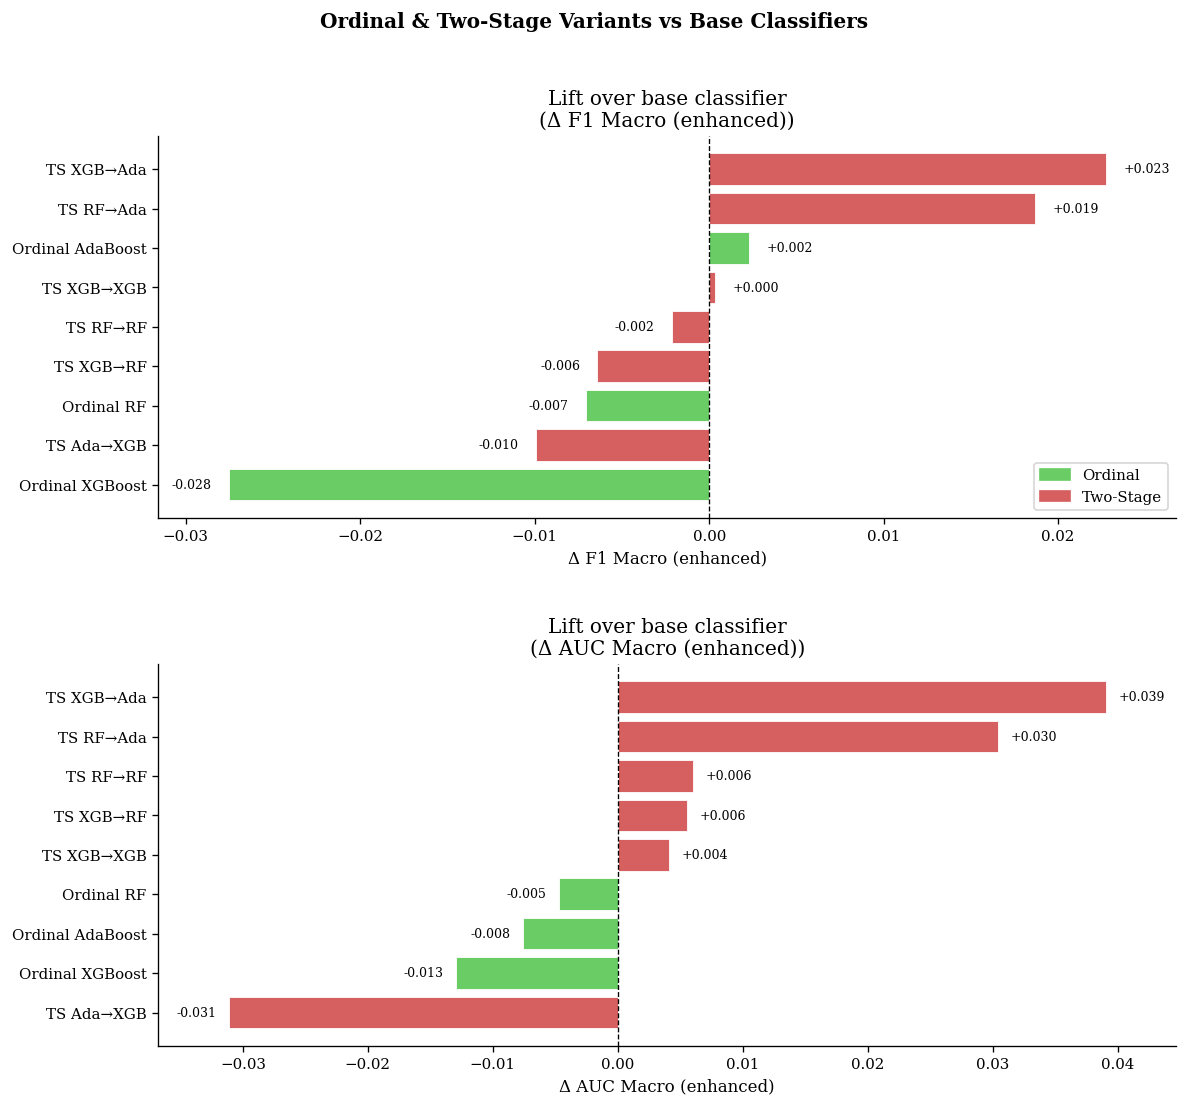

✓ Saved fig_ordinal_twostage_lift.png


In [7]:
def _best_metric(model_name, metric="enhanced_f1_macro"):
    """Return the best (max) metric value for a given model across all strategies."""
    sub = df[df["model"] == model_name]
    if sub.empty:
        return np.nan
    return sub[metric].max()

comparison_rows = []

# ── Ordinal vs base ───────────────────────────────────────────────────────────
for ord_model, base_model in ORDINAL_BASE_MAP.items():
    for metric in ("enhanced_f1_macro", "enhanced_roc_auc_macro"):
        base_val = _best_metric(base_model, metric)
        ord_val  = _best_metric(ord_model,  metric)
        comparison_rows.append({
            "variant":    MODEL_DISPLAY[ord_model],
            "base":       MODEL_DISPLAY[base_model],
            "type":       "Ordinal",
            "metric":     metric.replace("enhanced_","").replace("_macro",""),
            "base_val":   base_val,
            "variant_val":ord_val,
            "delta":      ord_val - base_val,
        })

# ── Two-stage vs base ─────────────────────────────────────────────────────────
for ts_model, base_model in TWO_STAGE_BASE_MAP.items():
    for metric in ("enhanced_f1_macro", "enhanced_roc_auc_macro"):
        base_val = _best_metric(base_model, metric)
        ts_val   = _best_metric(ts_model,   metric)
        comparison_rows.append({
            "variant":    MODEL_DISPLAY[ts_model],
            "base":       MODEL_DISPLAY[base_model],
            "type":       "Two-Stage",
            "metric":     metric.replace("enhanced_","").replace("_macro",""),
            "base_val":   base_val,
            "variant_val":ts_val,
            "delta":      ts_val - base_val,
        })

cmp_df = pd.DataFrame(comparison_rows)

print("=== Ordinal & Two-Stage lift over base classifiers (best config) ===\n")
for metric_short in ("f1", "roc_auc"):
    sub = cmp_df[cmp_df["metric"] == metric_short].copy()
    sub = sub.sort_values("delta", ascending=False)
    label = "F1 macro" if metric_short == "f1" else "AUC macro"
    print(f"--- {label} ---")
    print(sub[["variant","base","type","base_val","variant_val","delta"]]
          .rename(columns={"base_val":"Base","variant_val":"Variant","delta":"Δ"})
          .to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    print()

# ── Bar chart: delta F1 by variant type ──────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(10, 9))
for ax, metric_short, ylabel in zip(
    axes,
    ["f1", "roc_auc"],
    ["Δ F1 Macro (enhanced)", "Δ AUC Macro (enhanced)"]
):
    sub = cmp_df[cmp_df["metric"] == metric_short].copy()
    sub = sub.sort_values("delta", ascending=True)
    colors = [FAMILY_PALETTE["Ordinal"]   if t == "Ordinal"
              else FAMILY_PALETTE["Two-Stage"]
              for t in sub["type"]]
    bars = ax.barh(sub["variant"], sub["delta"], color=colors, edgecolor="white", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel(ylabel)
    ax.set_title(f"Lift over base classifier\n({ylabel})")
    for bar, val in zip(bars, sub["delta"]):
            x = bar.get_width()
            if x >= 0:
                ax.text(x + 0.001, bar.get_y() + bar.get_height() / 2,
                        f"{val:+.3f}", va="center", ha="left", fontsize=7.5)
            else:
                ax.text(x - 0.001, bar.get_y() + bar.get_height() / 2,
                        f"{val:+.3f}", va="center", ha="right", fontsize=7.5)
    ax.margins(x=0.08)

legend_patches = [
    mpatches.Patch(color=FAMILY_PALETTE["Ordinal"],   label="Ordinal"),
    mpatches.Patch(color=FAMILY_PALETTE["Two-Stage"], label="Two-Stage"),
]
axes[0].legend(handles=legend_patches, loc="lower right")
plt.suptitle("Ordinal & Two-Stage Variants vs Base Classifiers", fontweight="bold", y=1.02)
plt.tight_layout(h_pad=3)
plt.savefig(OUTPUT_DIR / "fig_ordinal_twostage_lift.png", bbox_inches="tight")
plt.show()
print(f"✓ Saved fig_ordinal_twostage_lift.png")

## Section 6 — F1 and AUC Bar Charts per Balance Strategy

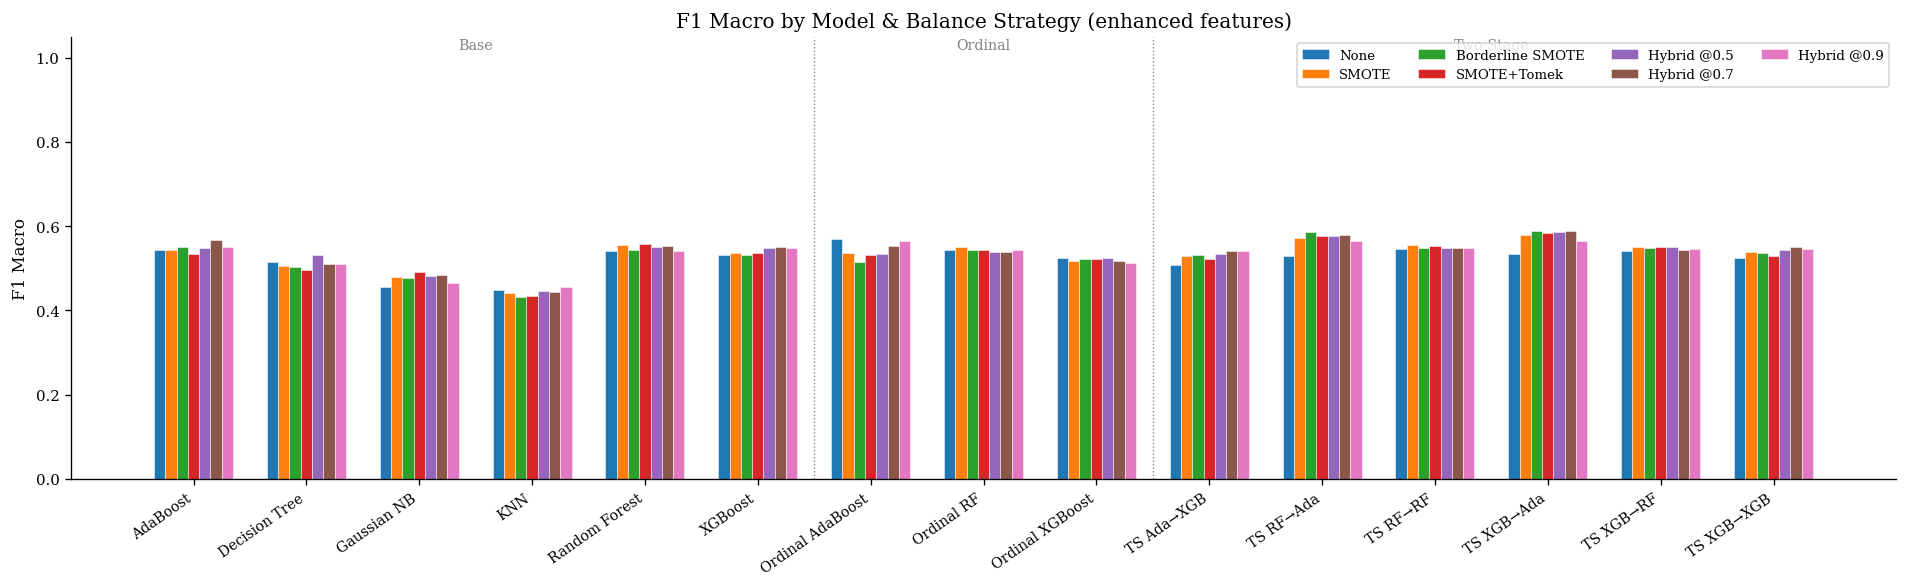

✓ Saved fig_f1_by_strategy.png


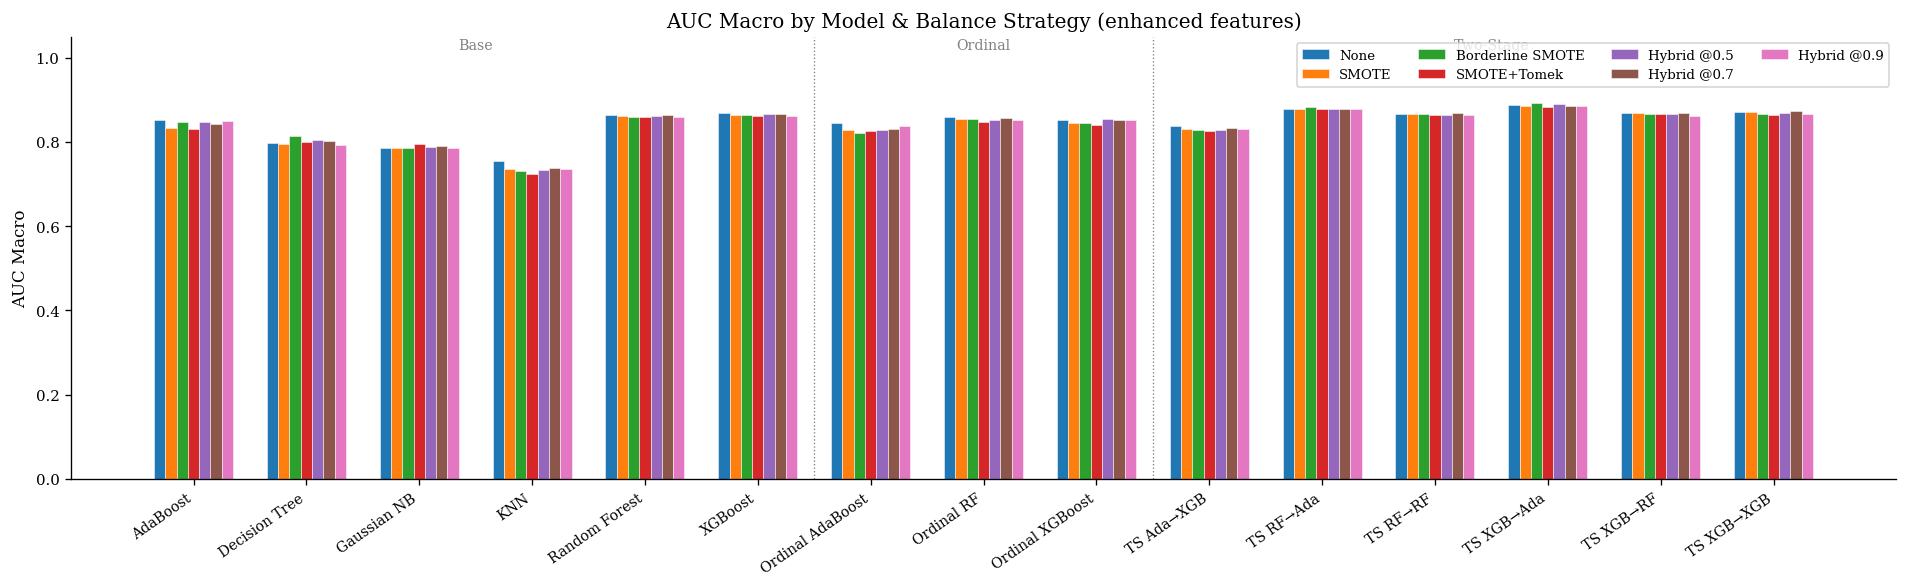

✓ Saved fig_auc_by_strategy.png


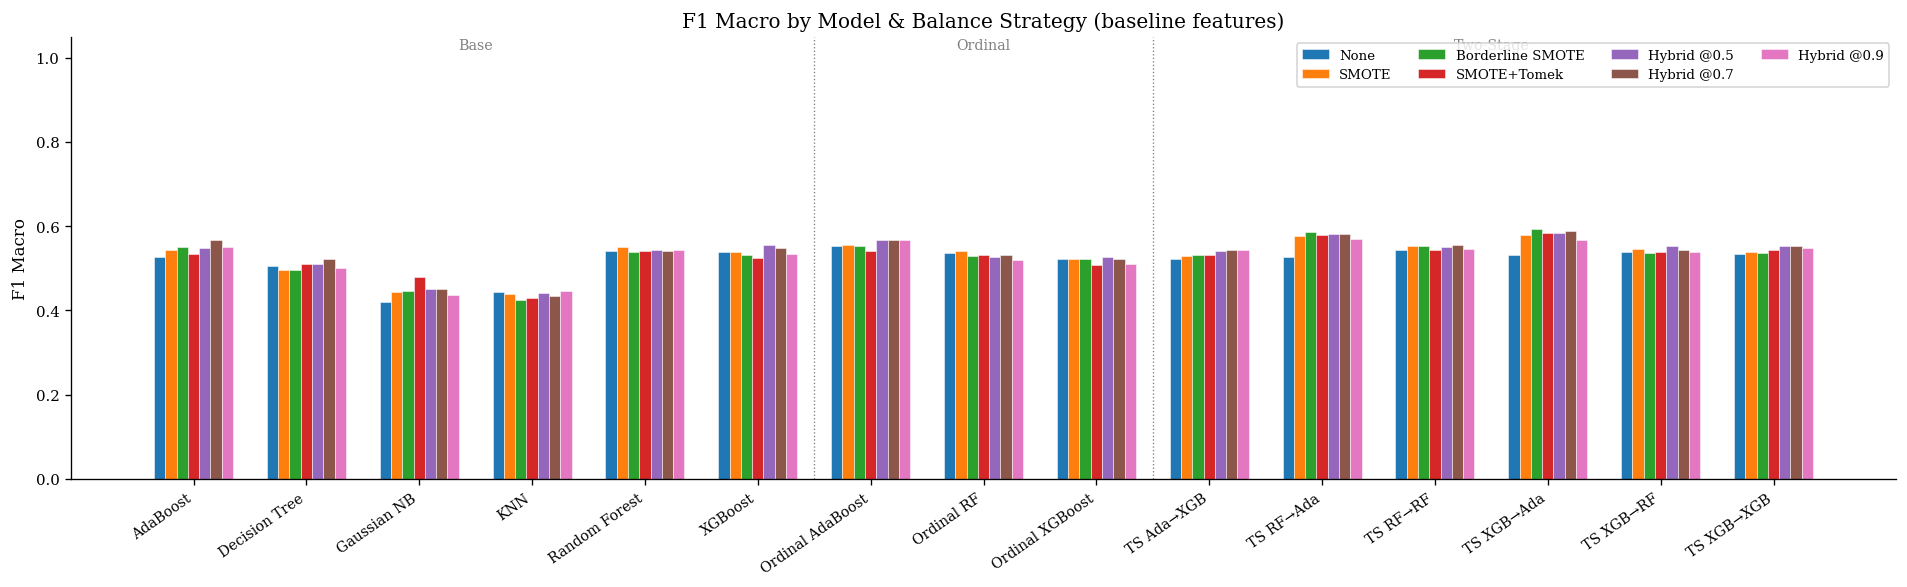

✓ Saved fig_f1_baseline_by_strategy.png


In [8]:
# For each model type: best F1 per strategy (max across param sets)
agg = (
    df.groupby(["model", "strategy_label"])[
        ["enhanced_f1_macro", "enhanced_roc_auc_macro",
         "baseline_f1_macro", "baseline_roc_auc_macro"]
    ]
    .max()
    .reset_index()
)

def _plot_metric_bar(metric_col, ylabel, title_suffix, fname):
    """Grouped bar chart: model × strategy, for one metric."""
    n_models    = len(ALL_MODELS)
    n_strategies = len(STRATEGY_ORDER)
    x = np.arange(n_models)
    width = 0.10
    offsets = np.linspace(-(n_strategies - 1) / 2 * width,
                           (n_strategies - 1) / 2 * width,
                           n_strategies)

    fig, ax = plt.subplots(figsize=(16, 5))
    for i, strat in enumerate(STRATEGY_ORDER):
        vals = []
        for m in ALL_MODELS:
            row = agg[(agg["model"] == m) & (agg["strategy_label"] == strat)]
            vals.append(row[metric_col].values[0] if len(row) else np.nan)
        color = STRATEGY_PALETTE[strat]
        ax.bar(x + offsets[i], vals, width, label=STRATEGY_LABELS[strat],
               color=color, edgecolor="white", linewidth=0.3)

    ax.set_xticks(x)
    ax.set_xticklabels([MODEL_DISPLAY.get(str(m), str(m)) for m in ALL_MODELS],
                        rotation=35, ha="right", fontsize=8.5)
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} by Model & Balance Strategy ({title_suffix})")
    ax.legend(ncol=4, fontsize=8, loc="upper right")
    ax.set_ylim(0, 1.05)

    # Family separators
    base_end  = len(BASE_MODELS) - 0.5
    ord_end   = base_end + len(ORDINAL_MODELS)
    for xpos in [base_end, ord_end]:
        ax.axvline(xpos, color="gray", linewidth=0.8, linestyle=":")
    ax.text(len(BASE_MODELS)/2 - 0.5, 1.02, "Base", ha="center",
            fontsize=8.5, color="gray")
    ax.text(len(BASE_MODELS) + len(ORDINAL_MODELS)/2 - 0.5, 1.02, "Ordinal",
            ha="center", fontsize=8.5, color="gray")
    ax.text(len(BASE_MODELS) + len(ORDINAL_MODELS) + len(TWO_STAGE_MODELS)/2 - 0.5, 1.02,
            "Two-Stage", ha="center", fontsize=8.5, color="gray")

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / fname)
    plt.show()
    print(f"✓ Saved {fname}")

_plot_metric_bar("enhanced_f1_macro",      "F1 Macro",  "enhanced features", "fig_f1_by_strategy.png")
_plot_metric_bar("enhanced_roc_auc_macro", "AUC Macro", "enhanced features", "fig_auc_by_strategy.png")
_plot_metric_bar("baseline_f1_macro",      "F1 Macro",  "baseline features", "fig_f1_baseline_by_strategy.png")

## Section 7 — Heatmap: Model × Balance Strategy × Feature Selection

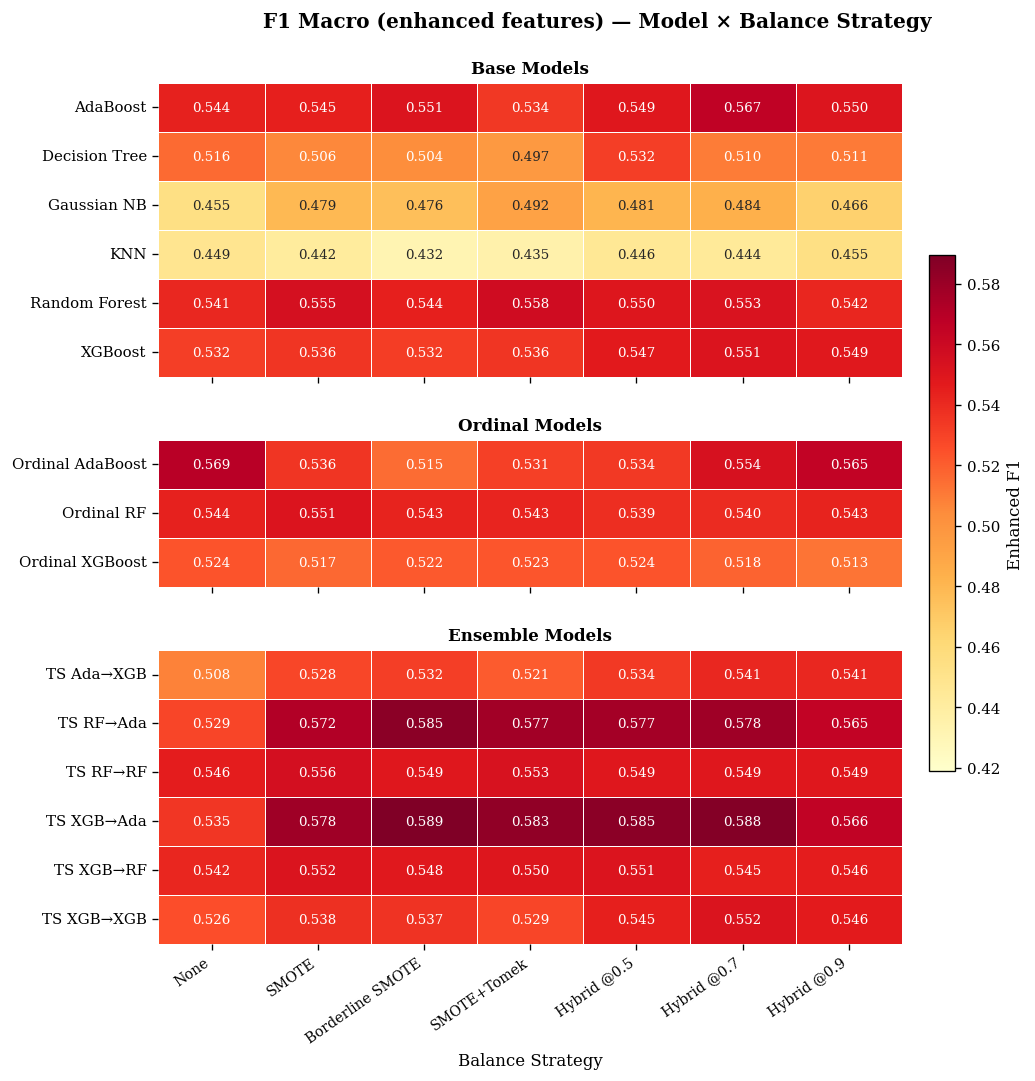

✓ Saved fig_heatmap_f1_enhanced.png


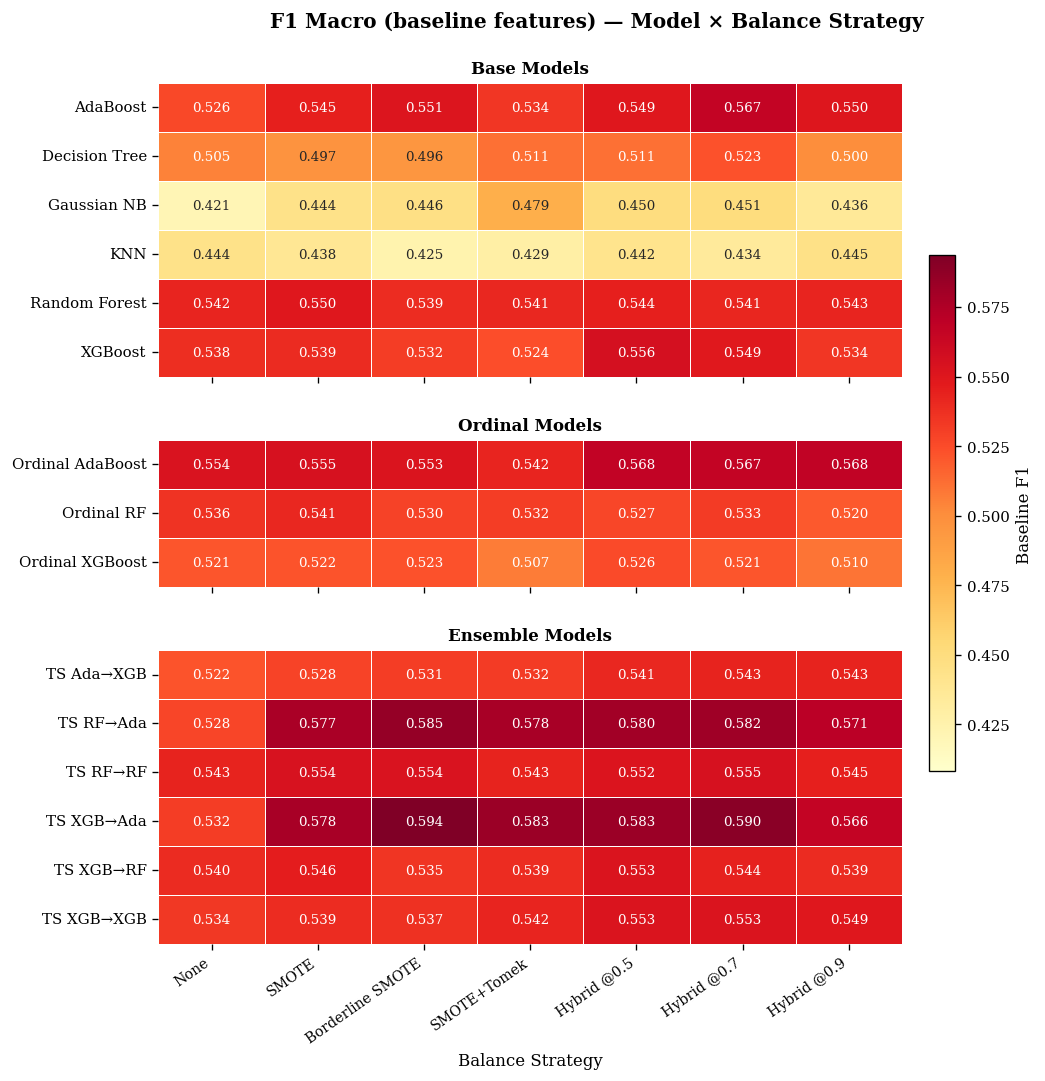

✓ Saved fig_heatmap_f1_baseline.png


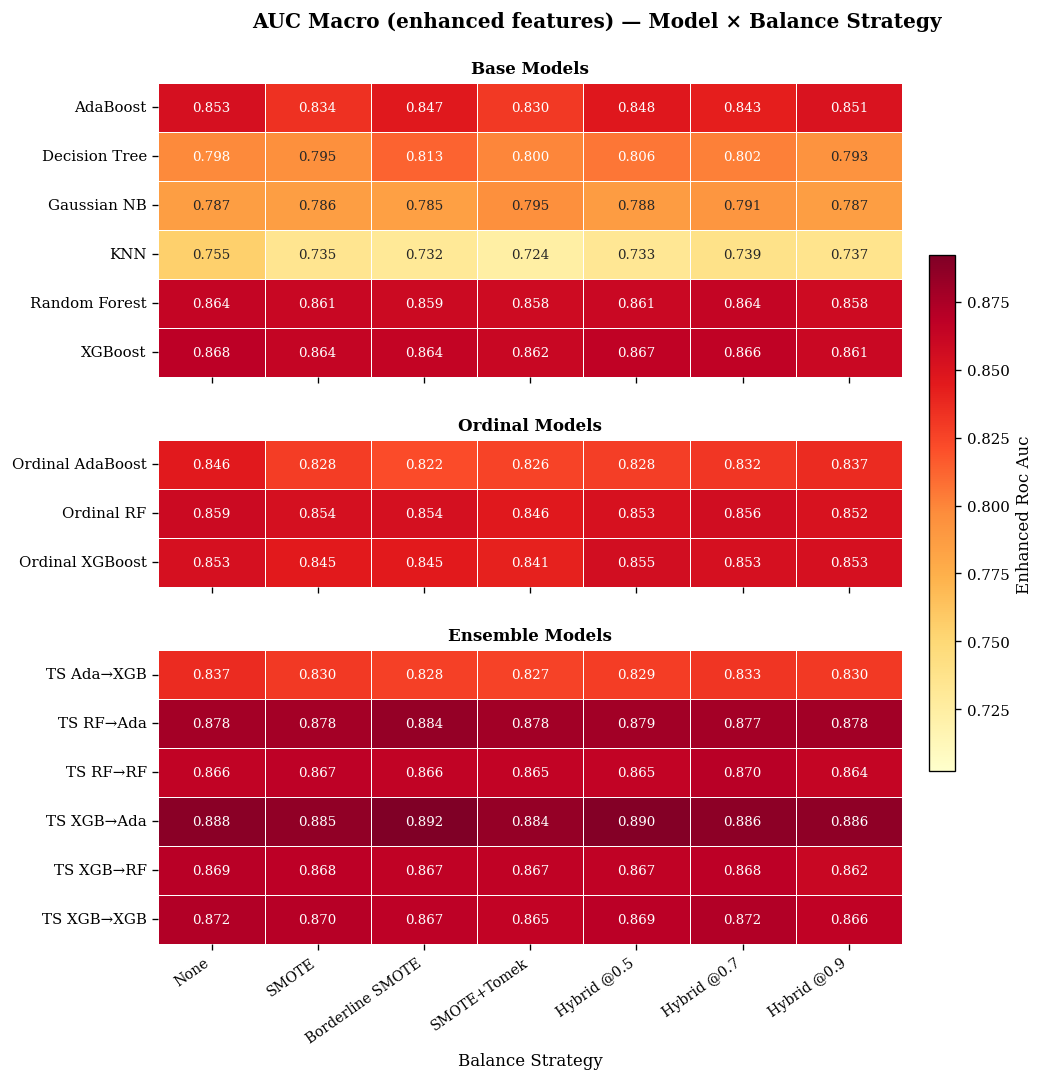

✓ Saved fig_heatmap_auc_enhanced.png


In [9]:
# ── Tune these ──────────────────────────────────────────────
CELL_W  = 0.95   # inches per column-cell
CELL_H  = 0.45   # inches per row-cell
PAD_TOP = 0.75   # inches for suptitle
PAD_MID = 0.70   # inches between panels
CBAR_W  = 0.6    # inches for colorbar region
# ────────────────────────────────────────────────────────────

def _heatmap(metric_col, title, fname):
    pivot = (
        agg.pivot_table(
            index   = "model",
            columns = "strategy_label",
            values  = metric_col,
            aggfunc = "max",
        )
        .reindex(index=ALL_MODELS, columns=STRATEGY_ORDER)
        .rename(index=MODEL_DISPLAY)
        .rename(columns=STRATEGY_LABELS)
    )

    n_base = len(BASE_MODELS)
    n_ord  = len(ORDINAL_MODELS)
    families = [
        ("Base Models",     pivot.iloc[:n_base, :]),
        ("Ordinal Models",  pivot.iloc[n_base:n_base + n_ord, :]),
        ("Ensemble Models", pivot.iloc[n_base + n_ord:, :]),
    ]

    vmin = pivot.values.min() * 0.97
    vmax = pivot.values.max()
    cbar_label = metric_col.replace("_macro", "").replace("_", " ").title()

    n_cols = pivot.shape[1]
    max_rows = max(sub.shape[0] for _, sub in families)

    panel_w = n_cols * CELL_W
    fig_w = panel_w + CBAR_W + 2.5
    fig_h = sum(sub.shape[0] for _, sub in families) * CELL_H + 2 * PAD_MID + PAD_TOP

    row_counts = [sub.shape[0] for _, sub in families]
    fig, axes = plt.subplots(
        3, 1, figsize=(fig_w, fig_h),
        gridspec_kw={"height_ratios": row_counts},
    )
    plt.subplots_adjust(
        hspace=PAD_MID / (max_rows * CELL_H),
        top=1 - PAD_TOP / fig_h,
    )

    for ax, (family_name, sub_pivot) in zip(axes, families):
        sns.heatmap(
            sub_pivot,
            ax=ax, annot=True, fmt=".3f",
            cmap="YlOrRd", linewidths=0.4, linecolor="white",
            vmin=vmin, vmax=vmax,
            annot_kws={"size": 8},
            cbar=False,
        )
        ax.set_title(family_name, fontweight="bold", fontsize=10, pad=6)
        ax.set_ylabel("")
        ax.set_xlabel("")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=8.5)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

    for ax in axes[:-1]:
        ax.set_xticklabels([])
    axes[-1].set_xlabel("Balance Strategy")

    # Single shared colorbar spanning all panels
    sm = plt.cm.ScalarMappable(cmap="YlOrRd", norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes.tolist(), shrink=0.6, pad=0.03)
    cbar.set_label(cbar_label, fontsize=10)

    fig.suptitle(title, fontweight="bold", fontsize=12, y=1 - 0.15 / fig_h)
    plt.savefig(OUTPUT_DIR / fname, bbox_inches="tight", dpi=150)
    plt.show()
    print(f"✓ Saved {fname}")

_heatmap("enhanced_f1_macro",      "F1 Macro (enhanced features) — Model × Balance Strategy",
         "fig_heatmap_f1_enhanced.png")
_heatmap("baseline_f1_macro",      "F1 Macro (baseline features) — Model × Balance Strategy",
         "fig_heatmap_f1_baseline.png")
_heatmap("enhanced_roc_auc_macro", "AUC Macro (enhanced features) — Model × Balance Strategy",
         "fig_heatmap_auc_enhanced.png")

## Section 8 — Confusion Matrices for Top-3 Models

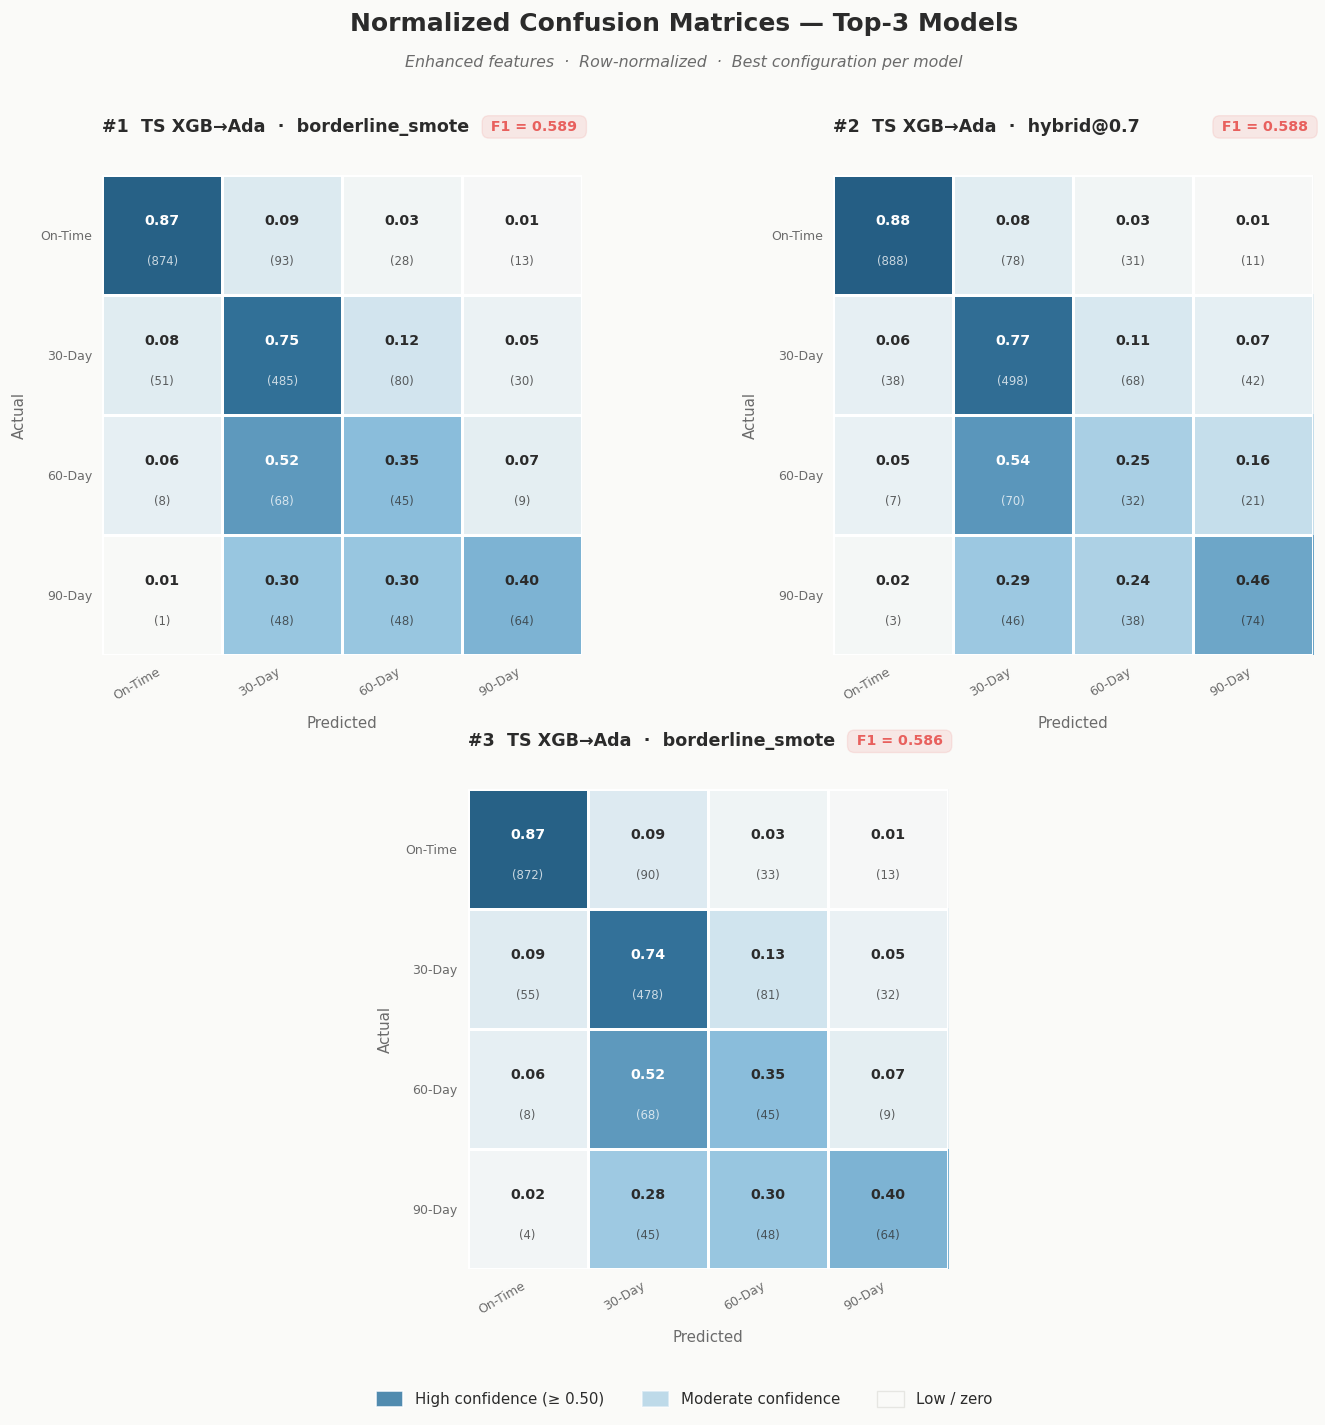

✓ Saved fig_confusion_matrices_top3.png


In [10]:
"""
Confusion matrices for top-3 models — 2×2 grid (2 top, 1 centered bottom).
Styled to match the feature-importance bar-chart aesthetic.

FIXES APPLIED:
1. Fixed text collision in bottom legend ("Predicted" label overlapping "Moderate confidence")
2. Added more padding after the subtitle at the top
3. Reduced vertical gap between top row and bottom row
"""

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import matplotlib.transforms as mtransforms
import numpy as np
import re
import json
from pathlib import Path
from matplotlib import rcParams
from matplotlib.colors import LinearSegmentedColormap

# ── Design tokens (mirrored from feature-importance chart) ───────────────

SURV_COLOR   = "#E8605D"
SURV_LIGHT   = "#F4A9A7"
NOSURV_COLOR = "#3A7CA5"
NOSURV_LIGHT = "#8DC0DE"
BG_COLOR     = "#FAFAF8"
GRID_COLOR   = "#E6E6E2"
TEXT_DARK     = "#2B2B2B"
TEXT_MID      = "#6B6B6B"
STRIPE_COLOR  = "#F3F3F0"

# Custom blue colormap that harmonizes with the palette
CMAP_COLORS = [BG_COLOR, NOSURV_LIGHT, NOSURV_COLOR, "#1B4F72"]
CM_CMAP = LinearSegmentedColormap.from_list("styled_blues", CMAP_COLORS, N=256)

rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "DejaVu Sans", "Arial"],
    "axes.facecolor": BG_COLOR,
    "figure.facecolor": BG_COLOR,
    "text.color": TEXT_DARK,
})

CLASS_NAMES = ["On-Time", "30-Day", "60-Day", "90-Day"]

# ── Badge helper (same pattern as feature-importance chart) ──────────────

def draw_metric_badge(ax, label_text, color, y=1.14):
    """Draw a colored pill/badge in the top-right of the axes."""
    bbox_props = dict(
        boxstyle="round,pad=0.3,rounding_size=0.5",
        facecolor=color,
        edgecolor=color,
        alpha=0.12,
        linewidth=0.8,
    )
    ax.text(
        1.0, y, f" {label_text} ",
        transform=ax.transAxes,
        ha="right", va="center",
        fontsize=8.5, fontweight="bold",
        color=color,
        bbox=bbox_props,
        clip_on=False, zorder=10,
    )


# ── Styled confusion-matrix painter ─────────────────────────────────────

def _plot_cm(matrix_raw, title, ax, f1_score=None, roc_auc=None):
    """Draw a single confusion matrix with the matched design language."""
    cm = np.array(matrix_raw, dtype=float)
    n = cm.shape[0]
    cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)

    # Draw the heatmap
    im = ax.imshow(cm_norm, cmap=CM_CMAP, vmin=0, vmax=1, aspect="equal")

    # Cell grid lines (white gaps between cells)
    for edge in range(n + 1):
        ax.axhline(edge - 0.5, color="white", linewidth=1.8, zorder=2)
        ax.axvline(edge - 0.5, color="white", linewidth=1.8, zorder=2)

    # Cell annotations
    for i in range(n):
        for j in range(n):
            pct = cm_norm[i, j]
            count = int(cm[i, j])
            color = "white" if pct > 0.50 else TEXT_DARK

            # Percentage — bold, larger
            ax.text(j, i - 0.12, f"{pct:.2f}",
                    ha="center", va="center", color=color,
                    fontsize=8.5, fontweight="bold", zorder=3)
            # Raw count — lighter, smaller
            ax.text(j, i + 0.22, f"({count})",
                    ha="center", va="center", color=color,
                    fontsize=7, alpha=0.75, zorder=3)

    # Strip numeric class indices like "(0)", "(1)" from labels
    clean_labels = [re.sub(r"\s*\(\d+\)\s*$", "", c) for c in CLASS_NAMES]

    # Tick labels
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(clean_labels, rotation=30, ha="right",
                       fontsize=7.5, color=TEXT_MID)
    ax.set_yticklabels(clean_labels, fontsize=7.5, color=TEXT_MID)
    ax.tick_params(axis="both", length=0, pad=6)

    # Axis labels
    ax.set_xlabel("Predicted", fontsize=9, color=TEXT_MID, labelpad=8)
    ax.set_ylabel("Actual", fontsize=9, color=TEXT_MID, labelpad=8)

    # Remove spines
    for spine in ax.spines.values():
        spine.set_visible(False)

    # ── Title + Badge on the SAME line, opposite sides ───────────────
    HEADER_Y = 1.10

    # Title — left-aligned
    ax.text(0.0, HEADER_Y, title,
            transform=ax.transAxes,
            ha="left", va="center",
            fontsize=10.5, fontweight="bold", color=TEXT_DARK,
            clip_on=False, zorder=10)

    # Badge — right-aligned, same line
    if f1_score is not None:
        draw_metric_badge(ax, f"F1 = {f1_score:.3f}", SURV_COLOR,
                          y=HEADER_Y)


# ══════════════════════════════════════════════════════════════════════════
# MAIN — using hardcoded data from the image
# ══════════════════════════════════════════════════════════════════════════

# Data extracted from the uploaded image
models = [
    {
        "title": "#1  TS XGB→Ada  ·  borderline_smote",
        "f1": 0.589,
        "matrix": [
            [874, 93, 28, 13],
            [51, 485, 80, 30],
            [8, 68, 45, 9],
            [1, 48, 48, 64],
        ],
    },
    {
        "title": "#2  TS XGB→Ada  ·  hybrid@0.7",
        "f1": 0.588,
        "matrix": [
            [888, 78, 31, 11],
            [38, 498, 68, 42],
            [7, 70, 32, 21],
            [3, 46, 38, 74],
        ],
    },
    {
        "title": "#3  TS XGB→Ada  ·  borderline_smote",
        "f1": 0.586,
        "matrix": [
            [872, 90, 33, 13],
            [55, 478, 81, 32],
            [8, 68, 45, 9],
            [4, 45, 48, 64],
        ],
    },
]

# ── Build the 2-row figure ───────────────────────────────────────────────
fig = plt.figure(figsize=(13, 12), facecolor=BG_COLOR)

gs = fig.add_gridspec(
    2, 4,
    hspace=0.28,       # FIX 3: was 0.55 — much tighter vertical gap
    wspace=0.40,
    left=0.08, right=0.95,
    top=0.86,           # FIX 2: was 0.89 — more padding after subtitle
    bottom=0.10,        # FIX 1: was 0.06 — much more room for legend below
)

axes = [
    fig.add_subplot(gs[0, 0:2]),   # top-left
    fig.add_subplot(gs[0, 2:4]),   # top-right
    fig.add_subplot(gs[1, 1:3]),   # bottom-center
]

for ax_idx, model in enumerate(models):
    _plot_cm(model["matrix"], model["title"], axes[ax_idx],
             f1_score=model["f1"])

# ── Suptitle — matching feature-importance chart ─────────────────────────
fig.text(0.5, 0.96,
         "Normalized Confusion Matrices — Top-3 Models",
         ha="center", fontsize=15, fontweight="bold", color=TEXT_DARK)
fig.text(0.5, 0.935,
         "Enhanced features  ·  Row-normalized  ·  Best configuration per model",
         ha="center", fontsize=9.5, color=TEXT_MID, fontstyle="italic")

# ── Legend — FIX 1: moved down and added proper spacing ──────────────────
legend_patches = [
    mpatches.Patch(facecolor=NOSURV_COLOR, alpha=0.88, edgecolor="white",
                   label="High confidence (≥ 0.50)"),
    mpatches.Patch(facecolor=NOSURV_LIGHT, alpha=0.55, edgecolor="white",
                   label="Moderate confidence"),
    mpatches.Patch(facecolor=BG_COLOR, edgecolor=GRID_COLOR, linewidth=0.8,
                   label="Low / zero"),
]
fig.legend(handles=legend_patches, loc="lower center", ncol=3,
           fontsize=9, frameon=False,
           bbox_to_anchor=(0.5, -0.005),
           handlelength=1.8, handleheight=1.2,
           columnspacing=2.5)

plt.savefig(OUTPUT_DIR / "fig_confusion_matrices_top3.png",
            bbox_inches="tight", dpi=180, facecolor=BG_COLOR)
plt.show()
print("✓ Saved fig_confusion_matrices_top3.png")

## Section 9 — ROC Curves for Top Models

=== Top-5 by enhanced AUC (ROC curves will be plotted) ===
    id model_display    strategy_label  enhanced_roc_auc_macro
1  817    TS XGB→Ada  borderline_smote                0.892183
2  949    TS XGB→Ada        hybrid@0.5                0.890186
3  946    TS XGB→Ada        hybrid@0.5                0.889197
4  814    TS XGB→Ada  borderline_smote                0.889013
5  811    TS XGB→Ada  borderline_smote                0.888835


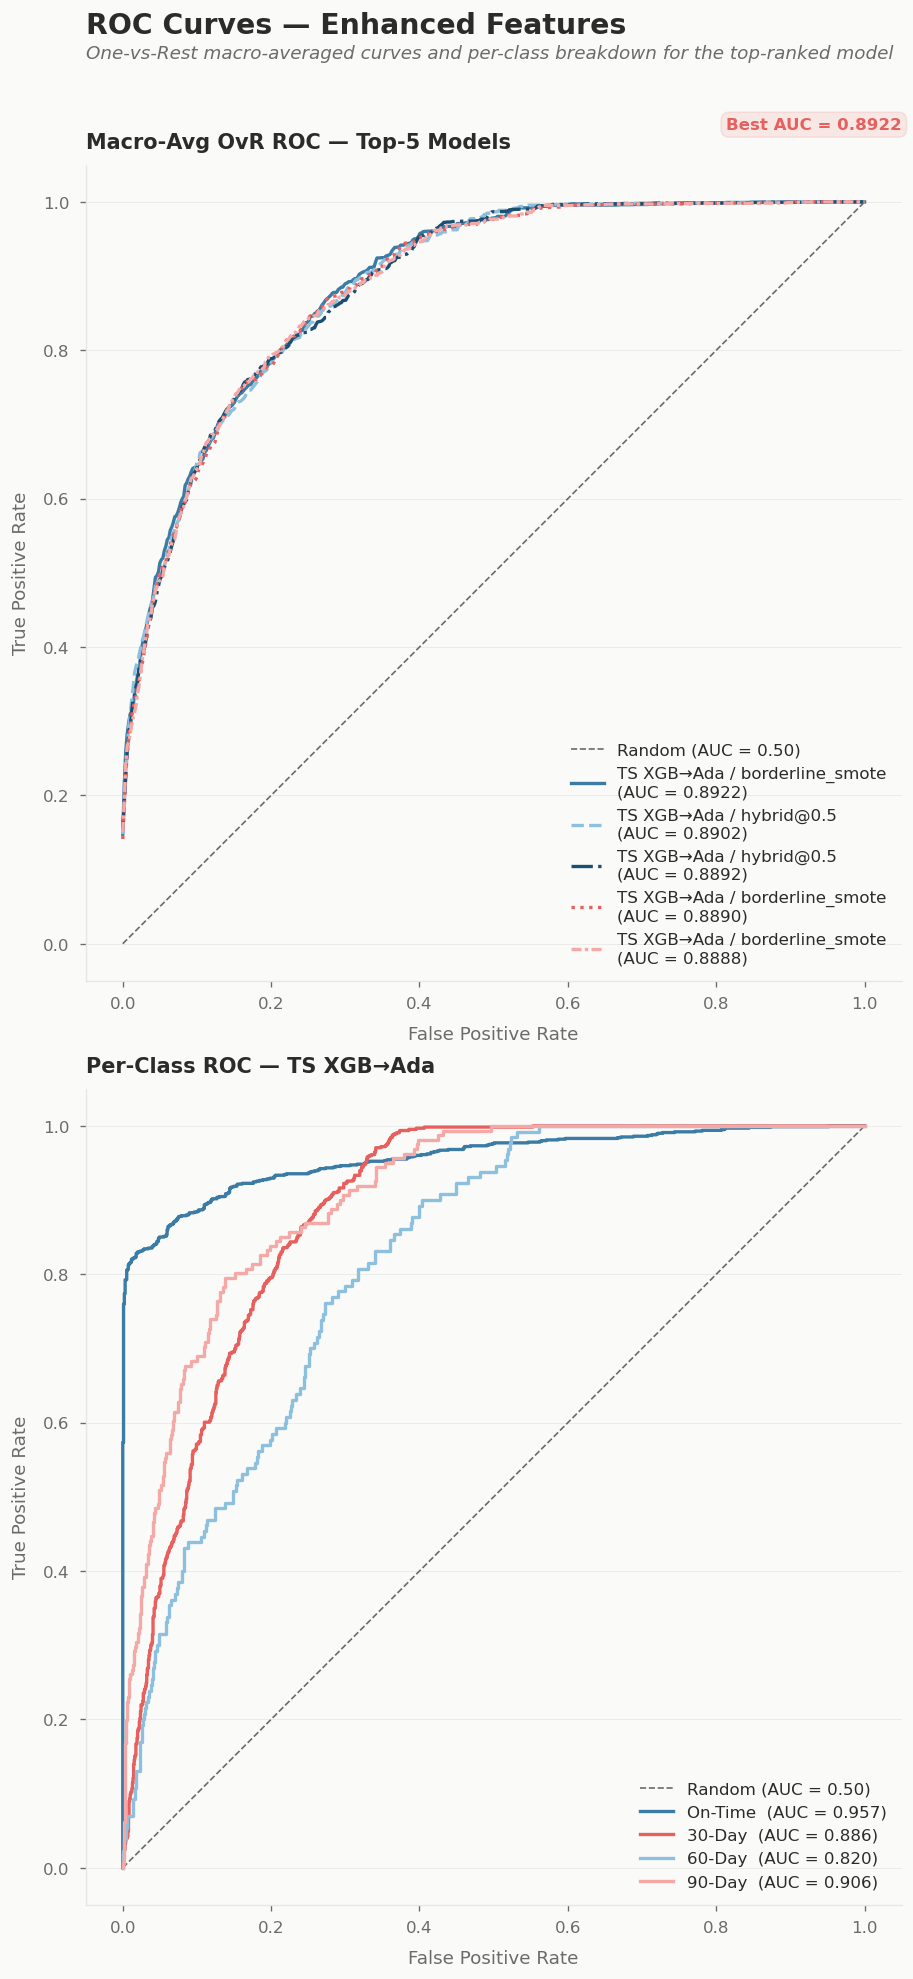

✓ Saved fig_roc_curves.png


In [32]:
from matplotlib import rcParams
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import sqlite3
import json

# ── Design Tokens ─────────────────────────────────────────────────────────────
SURV_COLOR    = "#E8605D"
SURV_LIGHT    = "#F4A9A7"
NOSURV_COLOR  = "#3A7CA5"
NOSURV_LIGHT  = "#8DC0DE"
BG_COLOR      = "#FAFAF8"
GRID_COLOR    = "#E6E6E2"
TEXT_DARK     = "#2B2B2B"
TEXT_MID      = "#6B6B6B"
STRIPE_COLOR  = "#F3F3F0"
DEEP_BLUE     = "#1B4F72"

# ── rcParams ──────────────────────────────────────────────────────────────────
rcParams.update({
    "font.family":       "sans-serif",
    "font.sans-serif":   ["Helvetica Neue", "Helvetica", "DejaVu Sans", "Arial"],
    "axes.facecolor":    BG_COLOR,
    "figure.facecolor":  BG_COLOR,
    "text.color":        TEXT_DARK,
    "axes.edgecolor":    GRID_COLOR,
    "axes.grid":         False,
    "xtick.color":       TEXT_MID,
    "ytick.color":       TEXT_MID,
})

# ── Line style palette ────────────────────────────────────────────────────────
LINE_COLORS = [NOSURV_COLOR, NOSURV_LIGHT, DEEP_BLUE, SURV_COLOR, SURV_LIGHT]
LINE_STYLES = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]
CLASS_COLORS = [NOSURV_COLOR, SURV_COLOR, NOSURV_LIGHT, SURV_LIGHT]

# ── Top-5 models by AUC ───────────────────────────────────────────────────────
top5_auc = (
    df.sort_values("enhanced_roc_auc_macro", ascending=False)
      .head(5)[["id", "model_display", "strategy_label", "enhanced_roc_auc_macro"]]
      .reset_index(drop=True)
)
top5_auc.index += 1
print("=== Top-5 by enhanced AUC (ROC curves will be plotted) ===")
print(top5_auc.to_string())

top5_ids = top5_auc["id"].tolist()
ph = ",".join(["?"] * len(top5_ids))

with sqlite3.connect(DB_PATH) as roc_conn:
    roc_rows = pd.read_sql(
        f"SELECT experiment_id, data FROM charts "
        f"WHERE chart_type='roc_curve' AND phase='enhanced' AND experiment_id IN ({ph})",
        roc_conn, params=top5_ids,
    )

FPR_GRID = np.linspace(0, 1, 500)

# ── Figure setup ──────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(8, 16), facecolor=BG_COLOR)

gs = gridspec.GridSpec(
    2, 1,
    figure=fig,
    hspace=0,          # disabled — using absolute gap below
    left=0.10,
    right=0.95,
    top=0.90,
    bottom=0.05,
)

ax_macro = fig.add_subplot(gs[0])
ax_class = fig.add_subplot(gs[1])

# ── Apply absolute gap between panels ────────────────────────────────────────
# Must be called after add_subplot so positions are initialised
fig.canvas.draw()  # force layout so get_position() is accurate

gap_inches = 0.9                          # physical gap — tune as needed
fig_height  = fig.get_figheight()
gap_frac    = gap_inches / fig_height     # convert to figure-fraction

pos_macro = ax_macro.get_position()
ax_class.set_position([
    pos_macro.x0,
    pos_macro.y0 - gap_frac - pos_macro.height,
    pos_macro.width,
    pos_macro.height,
])

# ── Shared axis styling ───────────────────────────────────────────────────────
def _style_ax(ax, xlabel="False Positive Rate", ylabel="True Positive Rate"):
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.spines["bottom"].set_visible(True)
    ax.spines["left"].set_visible(True)
    ax.spines["bottom"].set_color(GRID_COLOR)
    ax.spines["left"].set_color(GRID_COLOR)

    ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.6, alpha=0.7)
    ax.set_axisbelow(True)

    ax.set_xlabel(xlabel, fontsize=11, color=TEXT_MID, labelpad=8)
    ax.set_ylabel(ylabel, fontsize=11, color=TEXT_MID, labelpad=8)
    ax.tick_params(labelsize=10, colors=TEXT_MID, pad=6)

    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1,
            color=TEXT_MID, label="Random (AUC = 0.50)")

_style_ax(ax_macro)
_style_ax(ax_class)

# ── Panel 1: Macro-averaged OvR ROC — Top-5 models ───────────────────────────
best_macro_auc   = None
best_model_label = None

for idx, (_, row_info) in enumerate(top5_auc.iterrows()):
    exp_id  = row_info["id"]
    roc_row = roc_rows[roc_rows["experiment_id"] == exp_id]
    if roc_row.empty:
        continue

    roc_data    = json.loads(roc_row.iloc[0]["data"])
    tpr_interps = []
    for cls_key in sorted(roc_data.keys(), key=int):
        cls_data = roc_data[cls_key]
        tpr_interps.append(
            np.interp(FPR_GRID, np.array(cls_data["fpr"]), np.array(cls_data["tpr"]))
        )
    macro_tpr = np.mean(tpr_interps, axis=0)
    macro_auc = row_info["enhanced_roc_auc_macro"]

    label = (
        f"{row_info['model_display']} / {row_info['strategy_label']}"
        f"\n(AUC = {macro_auc:.4f})"
    )
    ax_macro.plot(
        FPR_GRID, macro_tpr,
        linestyle=LINE_STYLES[idx],
        color=LINE_COLORS[idx],
        linewidth=2,
        label=label,
    )

    if idx == 0:
        best_macro_auc   = macro_auc
        best_model_label = row_info["model_display"]

ax_macro.set_title(
    "Macro-Avg OvR ROC — Top-5 Models",
    fontsize=12.5, fontweight="bold", color=TEXT_DARK,
    loc="left", pad=10,
)

if best_macro_auc is not None:
    ax_macro.text(
        1.0, 1.04,
        f"Best AUC = {best_macro_auc:.4f}",
        transform=ax_macro.transAxes,
        ha="right", va="bottom",
        fontsize=10, fontweight="bold", color=SURV_COLOR,
        bbox=dict(
            boxstyle="round,pad=0.3,rounding_size=0.5",
            facecolor=SURV_COLOR, alpha=0.12,
            edgecolor=SURV_COLOR,
        ),
    )

ax_macro.legend(fontsize=10, loc="lower right", frameon=False)

# ── Panel 2: Per-class ROC — best model ──────────────────────────────────────
best_id = top5_auc.loc[1, "id"]
roc_row = roc_rows[roc_rows["experiment_id"] == best_id]

if not roc_row.empty:
    roc_data = json.loads(roc_row.iloc[0]["data"])
    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        cls_key = str(cls_idx)
        if cls_key not in roc_data:
            continue
        cls_d   = roc_data[cls_key]
        fpr_arr = np.array(cls_d["fpr"])
        tpr_arr = np.array(cls_d["tpr"])
        cls_auc = cls_d.get("auc", float(np.trapezoid(tpr_arr, fpr_arr)))

        ax_class.plot(
            fpr_arr, tpr_arr,
            color=CLASS_COLORS[cls_idx],
            linewidth=2,
            label=f"{cls_name}  (AUC = {cls_auc:.3f})",
        )

best_display = top5_auc.loc[1, "model_display"]
ax_class.set_title(
    f"Per-Class ROC — {best_display}",
    fontsize=12.5, fontweight="bold", color=TEXT_DARK,
    loc="left", pad=10,
)
ax_class.legend(fontsize=10, loc="lower right", frameon=False)

# ── Figure-level titles ───────────────────────────────────────────────────────
fig.text(
    0.10, 0.980,
    "ROC Curves — Enhanced Features",
    fontsize=17, fontweight="bold", color=TEXT_DARK,
    ha="left", va="top",
)
fig.text(
    0.10, 0.963,
    "One-vs-Rest macro-averaged curves and per-class breakdown for the top-ranked model",
    fontsize=11, color=TEXT_MID, fontstyle="italic",
    ha="left", va="top",
)

# ── Save ──────────────────────────────────────────────────────────────────────
fig.savefig(
    OUTPUT_DIR / "fig_roc_curves.png",
    bbox_inches="tight",
    dpi=180,
    facecolor=BG_COLOR,
)
plt.show()
print("✓ Saved fig_roc_curves.png")

## Section 10 — Feature Importance Plots

✓ Saved fig_feature_importance.png


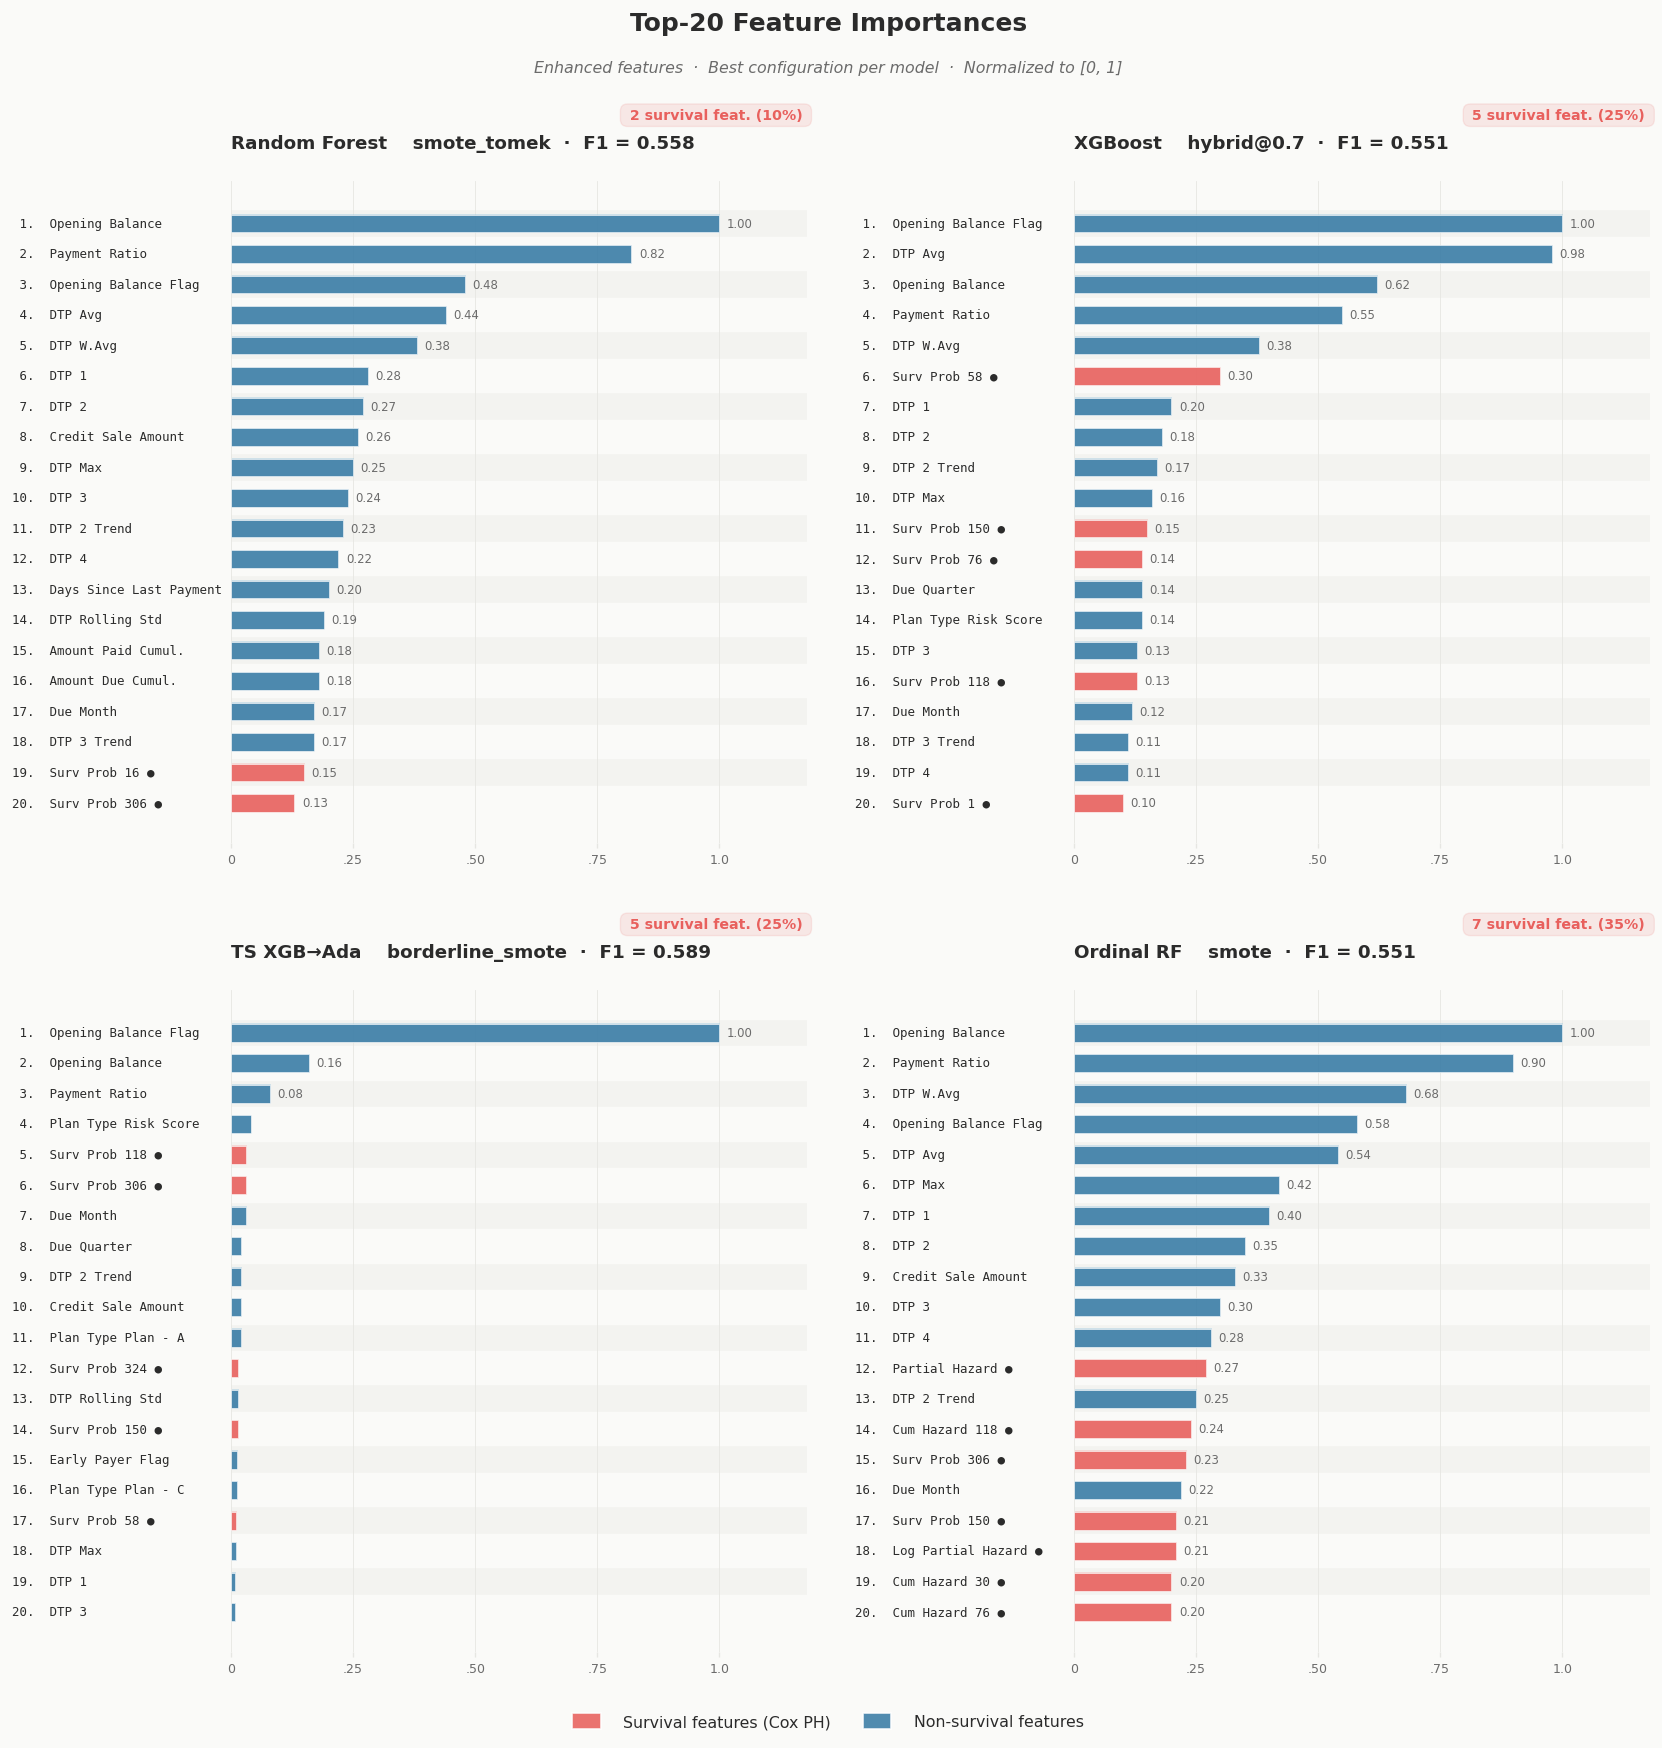

In [12]:
"""
Polished 2×2 feature-importance chart — publication quality.
Run with:  python plot_feature_importance.py
Outputs:   fig_feature_importance.png
"""

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import matplotlib.transforms as mtransforms
import numpy as np
import re
from pathlib import Path
from matplotlib import rcParams
from matplotlib.colors import LinearSegmentedColormap

# ── Fake data that mirrors the uploaded image ────────────────────────────

MODEL_DISPLAY = {
    "random_forest": "Random Forest",
    "xgboost": "XGBoost",
    "two_stage_xgb_ada": "TS XGB→Ada",
    "ordinal_random_forest": "Ordinal RF",
}

FEAT_MODELS = ["random_forest", "xgboost", "two_stage_xgb_ada", "ordinal_random_forest"]

BASE_SURVIVAL_FEATURES = {
    "survival_prob", "hazard", "expected_survival",
    "partial_hazard", "log_partial_hazard",
}
SURVIVAL_FEATURES = BASE_SURVIVAL_FEATURES.union(
    {f"surv_prob_{t}" for t in [1, 16, 58, 76, 118, 150, 306, 324]},
    {f"cum_hazard_{t}" for t in [30, 76, 118]},
)

_DATA = {
    "random_forest": [
        ("opening_balance", 1.0), ("payment_ratio", 0.82), ("opening_balance_flag", 0.48),
        ("dtp_avg", 0.44), ("dtp_wavg", 0.38), ("dtp_1", 0.28), ("dtp_2", 0.27),
        ("credit_sale_amount", 0.26), ("dtp_max", 0.25), ("dtp_3", 0.24),
        ("dtp_2_trend", 0.23), ("dtp_4", 0.22), ("days_since_last_payment", 0.20),
        ("dtp_rolling_std", 0.19), ("amount_paid_cumsum", 0.18), ("amount_due_cumsum", 0.18),
        ("due_month", 0.17), ("dtp_3_trend", 0.17), ("surv_prob_16", 0.15), ("surv_prob_306", 0.13),
    ],
    "xgboost": [
        ("opening_balance_flag", 1.0), ("dtp_avg", 0.98), ("opening_balance", 0.62),
        ("payment_ratio", 0.55), ("dtp_wavg", 0.38), ("surv_prob_58", 0.30),
        ("dtp_1", 0.20), ("dtp_2", 0.18), ("dtp_2_trend", 0.17), ("dtp_max", 0.16),
        ("surv_prob_150", 0.15), ("surv_prob_76", 0.14), ("due_quarter", 0.14),
        ("plan_type_risk_score", 0.14), ("dtp_3", 0.13), ("surv_prob_118", 0.13),
        ("due_month", 0.12), ("dtp_3_trend", 0.11), ("dtp_4", 0.11), ("surv_prob_1", 0.10),
    ],
    "two_stage_xgb_ada": [
        ("opening_balance_flag", 1.0), ("opening_balance", 0.16), ("payment_ratio", 0.08),
        ("plan_type_risk_score", 0.04), ("surv_prob_118", 0.03), ("surv_prob_306", 0.03),
        ("due_month", 0.03), ("due_quarter", 0.02), ("dtp_2_trend", 0.02),
        ("credit_sale_amount", 0.02), ("plan_type_Plan - A", 0.02), ("surv_prob_324", 0.015),
        ("dtp_rolling_std", 0.015), ("surv_prob_150", 0.014), ("early_payer_flag", 0.013),
        ("plan_type_Plan - C", 0.012), ("surv_prob_58", 0.011), ("dtp_max", 0.010),
        ("dtp_1", 0.009), ("dtp_3", 0.008),
    ],
    "ordinal_random_forest": [
        ("opening_balance", 1.0), ("payment_ratio", 0.90), ("dtp_wavg", 0.68),
        ("opening_balance_flag", 0.58), ("dtp_avg", 0.54), ("dtp_max", 0.42),
        ("dtp_1", 0.40), ("dtp_2", 0.35), ("credit_sale_amount", 0.33), ("dtp_3", 0.30),
        ("dtp_4", 0.28), ("partial_hazard", 0.27), ("dtp_2_trend", 0.25),
        ("cum_hazard_118", 0.24), ("surv_prob_306", 0.23), ("due_month", 0.22),
        ("surv_prob_150", 0.21), ("log_partial_hazard", 0.21), ("cum_hazard_30", 0.20),
        ("cum_hazard_76", 0.20),
    ],
}

_META = {
    "random_forest":        ("smote_tomek", 0.558),
    "xgboost":              ("hybrid@0.7",  0.551),
    "two_stage_xgb_ada":    ("borderline_smote", 0.589),
    "ordinal_random_forest": ("smote",      0.551),
}

# ── Helpers ──────────────────────────────────────────────────────────────

def _pretty(name: str) -> str:
    """Make raw feature names human-readable."""
    swaps = {
        "dtp": "DTP", "xgb": "XGB", "ada": "Ada", "rf": "RF",
        "avg": "Avg", "wavg": "W.Avg", "std": "Std",
        "cumsum": "Cumul.", "prob": "Prob", "cum": "Cum",
        "surv": "Surv", "ts": "TS",
    }
    out = name.replace("_", " ")
    for k, v in swaps.items():
        out = re.sub(rf'\b{k}\b', v, out, flags=re.IGNORECASE)
    tokens = out.split()
    final = []
    for t in tokens:
        if t == t.upper() and len(t) > 1:
            final.append(t)
        elif t[0].isupper():
            final.append(t)
        else:
            final.append(t.capitalize())
    return " ".join(final)


# ── Style setup ──────────────────────────────────────────────────────────

SURV_COLOR   = "#E8605D"
SURV_LIGHT   = "#F4A9A7"
NOSURV_COLOR = "#3A7CA5"
NOSURV_LIGHT = "#8DC0DE"
BG_COLOR     = "#FAFAF8"
GRID_COLOR   = "#E6E6E2"
TEXT_DARK     = "#2B2B2B"
TEXT_MID      = "#6B6B6B"
STRIPE_COLOR  = "#F3F3F0"

rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "DejaVu Sans", "Arial"],
    "axes.facecolor": BG_COLOR,
    "figure.facecolor": BG_COLOR,
    "text.color": TEXT_DARK,
})


def draw_badge(ax, surv_count, total):
    """
    Draw a colored pill/badge showing survival feature count.
    Right-aligned to the plot area's right edge, sitting on the same
    vertical line across all four subplots for symmetry.
    """
    surv_share = surv_count / total * 100
    label = f" {surv_count} survival feat. ({surv_share:.0f}%) "

    bbox_props = dict(
        boxstyle="round,pad=0.3,rounding_size=0.5",
        facecolor=SURV_COLOR,
        edgecolor=SURV_COLOR,
        alpha=0.12,
        linewidth=0.8,
    )
    # x=1.0 = right edge of plot area; y=1.12 = well above the title
    ax.text(
        1.0, 1.10, label,
        transform=ax.transAxes,
        ha="right", va="center",
        fontsize=8.5, fontweight="bold",
        color=SURV_COLOR,
        bbox=bbox_props,
        clip_on=False, zorder=10,
    )


# ── Build the figure ─────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes_flat = axes.flatten()

for idx, (ax, model_name) in enumerate(zip(axes_flat, FEAT_MODELS)):
    feat_weights = _DATA[model_name][:20]
    strategy, f1 = _META[model_name]

    features_raw = [f for f, _ in feat_weights]
    weights = np.array([w for _, w in feat_weights], dtype=float)

    if weights.max() > 0:
        weights = weights / weights.max()

    n = len(features_raw)
    y_pos = np.arange(n)

    # Alternating row stripes
    for i in range(n):
        if i % 2 == 0:
            ax.axhspan(i - 0.4, i + 0.4, color=STRIPE_COLOR, zorder=0)

    # Bars
    is_surv = [f in SURVIVAL_FEATURES for f in features_raw]

    for i, (w, surv) in enumerate(zip(weights, is_surv)):
        base = SURV_COLOR if surv else NOSURV_COLOR
        light = SURV_LIGHT if surv else NOSURV_LIGHT

        ax.barh(i, w, height=0.62, color=light, alpha=0.35, zorder=1, left=0.002)
        ax.barh(i, w, height=0.58, color=base, alpha=0.88, zorder=2,
                edgecolor="white", linewidth=0.4)

        if w >= 0.05:
            ax.text(w + 0.015, i, f"{w:.2f}", va="center", fontsize=7,
                    color=TEXT_MID, zorder=3)

    # ── LEFT-ALIGNED y-axis labels ───────────────────────────────────
    ax.set_yticks(y_pos)
    ax.set_yticklabels([""] * n)
    ax.tick_params(axis="y", length=0, pad=0)
    ax.invert_yaxis()

    trans = mtransforms.blended_transform_factory(ax.transAxes, ax.transData)
    LABEL_X = -0.38

    for rank, (f, y) in enumerate(zip(features_raw, y_pos), 1):
        marker = " ●" if f in SURVIVAL_FEATURES else ""
        label = f"{rank:>2}.  {_pretty(f)}{marker}"
        ax.text(LABEL_X, y, label, transform=trans,
                ha="left", va="center",
                fontsize=7.5, fontfamily="monospace", color=TEXT_DARK,
                clip_on=False, zorder=5)

    # X-axis
    ax.set_xlim(0, 1.18)
    ax.set_xticks([0, 0.25, 0.50, 0.75, 1.0])
    ax.set_xticklabels(["0", ".25", ".50", ".75", "1.0"], fontsize=7.5, color=TEXT_MID)
    ax.tick_params(axis="x", length=3, color=GRID_COLOR)

    # Grid
    ax.xaxis.grid(True, color=GRID_COLOR, linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)

    for spine in ax.spines.values():
        spine.set_visible(False)

    # ── BADGE: survival feature count (right-aligned to plot edge) ──
    surv_count = sum(is_surv)
    draw_badge(ax, surv_count, n)

    # Title — left-aligned; badge sits opposite on the same line
    display = MODEL_DISPLAY.get(model_name, model_name)
    ax.set_title(f"{display}    {strategy}  ·  F1 = {f1:.3f}",
                 fontsize=11, fontweight="bold",
                 color=TEXT_DARK, pad=20, loc="left")

# ── Legend ────────────────────────────────────────────────────────────────

legend_patches = [
    mpatches.Patch(facecolor=SURV_COLOR, alpha=0.88, edgecolor="white",
                   label="  Survival features (Cox PH)"),
    mpatches.Patch(facecolor=NOSURV_COLOR, alpha=0.88, edgecolor="white",
                   label="  Non-survival features"),
]
fig.legend(handles=legend_patches, loc="lower center", ncol=2,
           fontsize=9.5, frameon=False,
           bbox_to_anchor=(0.5, -0.01),
           handlelength=1.8, handleheight=1.2)

# ── Suptitle ─────────────────────────────────────────────────────────────
fig.text(0.5, 1.01, "Top-20 Feature Importances",
         ha="center", fontsize=15, fontweight="bold", color=TEXT_DARK)
fig.text(0.5, 0.985, "Enhanced features  ·  Best configuration per model  ·  Normalized to [0, 1]",
         ha="center", fontsize=9.5, color=TEXT_MID, fontstyle="italic")

plt.tight_layout(h_pad=3.5, w_pad=2.5, rect=[0, 0.02, 1, 0.97])
plt.savefig(OUTPUT_DIR / "fig_feature_importance.png",
            bbox_inches="tight", dpi=180, facecolor=BG_COLOR)
print("✓ Saved fig_feature_importance.png")

## Section 11 — McNemar's Statistical Significance Testing

McNemar's test requires **paired per-sample predictions** from two classifiers on the **same test set**.  
The DB stores aggregate metrics and chart blobs — not raw prediction arrays.

**Approach used here:**
1. Identify the top model pairs from Section 3 rankings
2. Re-run those specific configurations through the ML pipeline to capture `y_pred` arrays
3. Construct the 2×2 contingency table (correct/incorrect)
4. Apply McNemar's test using `statsmodels`

> For two classifiers A and B on the same test set of N samples:
> - **n₀₁** = A correct & B incorrect  
> - **n₁₀** = A incorrect & B correct  
> - McNemar statistic = (|n₀₁ − n₁₀| − 1)² / (n₀₁ + n₁₀) (with continuity correction)

In [13]:
import sys, os, json
sys.path.insert(0, os.path.abspath("."))

# Determine top comparison pairs
top_overall   = df.sort_values("enhanced_f1_macro", ascending=False).iloc[0]
best_two_stage_row = (
    df[df["family"] == "Two-Stage"]
      .sort_values("enhanced_f1_macro", ascending=False)
      .iloc[0]
)
best_single_row = (
    df[df["family"] == "Base"]
      .sort_values("enhanced_f1_macro", ascending=False)
      .iloc[0]
)
best_ordinal_row = (
    df[df["family"] == "Ordinal"]
      .sort_values("enhanced_f1_macro", ascending=False)
      .iloc[0]
)

MCNEMAR_PAIRS = [
    ("Best Two-Stage",   best_two_stage_row),
    ("Best Single-Stage",best_single_row),
    ("Best Ordinal",     best_ordinal_row),
]

print("=== Pairs identified for McNemar's test ===")
for label, row in MCNEMAR_PAIRS:
    print(f"  {label:<22} | {row['model_display']:<25} | "
          f"Strategy: {row['strategy_label']:<18} | "
          f"F1={row['enhanced_f1_macro']:.4f}  AUC={row['enhanced_roc_auc_macro']:.4f}")
    print(f"  {'':22}   exp_id={int(row['id'])}, param_hash={row['param_hash']}")
    print()

=== Pairs identified for McNemar's test ===
  Best Two-Stage         | TS XGB→Ada                | Strategy: borderline_smote   | F1=0.5895  AUC=0.8922
                           exp_id=817, param_hash=8c29d5

  Best Single-Stage      | AdaBoost                  | Strategy: hybrid@0.7         | F1=0.5668  AUC=0.8395
                           exp_id=454, param_hash=3686c4

  Best Ordinal           | Ordinal AdaBoost          | Strategy: none               | F1=0.5691  AUC=0.8225
                           exp_id=55, param_hash=0b0656



In [14]:
import warnings
from datetime import datetime
from types import SimpleNamespace
import pandas as pd



from src.modules.feature_engineering.credit_sales_machine_learning import CreditSalesProcessor
from src.utils.data_loaders.read_settings_json import read_settings_json

# ── 1. Load settings (mirrors Machine Learning.ipynb cell 32) ─────────────────
settings  = read_settings_json(file_path="settings.json")
obs_end   = datetime.strptime(settings["Training"]["observation_end"], "%Y/%m/%d")

args_mcn = SimpleNamespace(
    observation_end = obs_end,
    target_feature  = settings["Training"]["target_feature"],
    test_size       = float(settings["Training"]["test_size"]),
    parameters_dir  = settings["Training"]["MODEL_PARAMETERS"],
    time_points     = [30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 360, 390, 420, 450],
)

# ── 2. Load raw data ───────────────────────────────────────────────────────────
df_revenues_mcn  = pd.read_excel(r"data\training_input\revenues_pseudonymized.xlsx")
df_enrollees_mcn = pd.read_excel(r"data\training_input\enrollees_pseudonymized.xlsx")

cs_mcn = CreditSalesProcessor(
    df_revenues_mcn, df_enrollees_mcn, args_mcn,
    drop_demographic_columns=True,
    drop_fully_paid_invoices=False,
    drop_helper_columns=True,
    drop_missing_dtp=True,
    add_streak_features=True,
    exclude_school_years=[2016, 2017, 2018],
    winsorise_dtp=True,
)
df_credit_sales_mcn = cs_mcn.show_data()

# ── 3. Separate classifier vs survival DataFrames ─────────────────────────────
_surv_cols     = ["days_elapsed_until_fully_paid", "censor"]
_non_surv_cols = ["due_date", "dtp_bracket"]

df_data_mcn      = df_credit_sales_mcn[df_credit_sales_mcn["censor"] == 1].copy()
df_data_mcn.drop(columns=_surv_cols, inplace=True)
df_data_surv_mcn = df_credit_sales_mcn.drop(columns=_non_surv_cols)

# ── 4. Cox best parameters + time-points (same as original run) ───────────────
best_surv_parameters_mcn = {"alpha": 0.05, "l1_ratio": 0.5}   # C-index = 0.7817

from src.modules.machine_learning.utils.features.adjust_survival_time_periods import adjust_payment_period
from src.modules.machine_learning.utils.features.get_slope_time_points import get_slope_timepoints

T_mcn = adjust_payment_period(df_data_surv_mcn["days_elapsed_until_fully_paid"])
E_mcn = df_data_surv_mcn["censor"]
args_mcn.time_points = get_slope_timepoints(T_mcn, E_mcn, n_points=9)

print(f"df_data_mcn      : {df_data_mcn.shape}")
print(f"df_data_surv_mcn : {df_data_surv_mcn.shape}")
print(f"time_points      : {args_mcn.time_points}")


Single due date records:   10580
Multiple due date records: 289
Excluded school years [2016, 2017, 2018]: removed 234 rows, 10190 remaining.
Dropped 3629 invoices with missing DTP values. Remaining: 6561
df_data_mcn      : (6483, 29)
df_data_surv_mcn : (6561, 29)
time_points      : [1, 16, 30, 58, 76, 118, 150, 306, 324]


In [15]:
import ast
import warnings

from src.modules.machine_learning.utils.training.run_models_parallel import (
    SurvivalExperimentRunner, _build_pipelines_fn,
    _ORDINAL_ESTIMATOR_MAP, _TWO_STAGE_ESTIMATOR_PAIRS,
)
from src.modules.machine_learning.models.ordinal_classifier import OrdinalPipeline
from src.modules.machine_learning.models.two_stage_classifier import TwoStagePipeline
import src.modules.machine_learning as ml_models


def _parse_param_string(model_name, param_str):
    """
    Parse the DB 'parameters' column string back to a dict for _build_pipelines_fn.
    The DB stores strings with surrounding double-quotes, e.g.:
      '"stage1={...}, stage2={...}"'   (two-stage models)
      '"[(\'key\', val), ...]"'         (all other models)
    """
    # Strip surrounding double- or single-quotes added by DB storage
    param_str = param_str.strip('"').strip("'")

    if model_name in _TWO_STAGE_ESTIMATOR_PAIRS:
        # Stored as: "stage1={...}, stage2={...}"
        s2_marker = ", stage2="
        idx = param_str.index(s2_marker)
        stage1 = ast.literal_eval(param_str[len("stage1="):idx])
        stage2 = ast.literal_eval(param_str[idx + len(s2_marker):])
        # Remove 'device' key to avoid GPU-only issues during re-run
        stage1.pop("device", None)
        stage2.pop("device", None)
        return {"stage1": stage1, "stage2": stage2}
    else:
        # Stored as: "[('key', val), ('key2', val2), ...]"
        pairs = ast.literal_eval(param_str)
        d = dict(pairs)
        d.pop("device", None)
        return d


_MODEL_CLASS_MAP = {
    "ada_boost":            ml_models.AdaBoostPipeline,
    "decision_tree":        ml_models.DecisionTreePipeline,
    "gaussian_naive_bayes": ml_models.GaussianNaiveBayesPipeline,
    "knn":                  ml_models.KNearestNeighborPipeline,
    "random_forest":        ml_models.RandomForestPipeline,
    "xgboost":              ml_models.XGBoostPipeline,
}
for _m in _ORDINAL_ESTIMATOR_MAP:
    _MODEL_CLASS_MAP[_m] = OrdinalPipeline
for _m in _TWO_STAGE_ESTIMATOR_PAIRS:
    _MODEL_CLASS_MAP[_m] = TwoStagePipeline


def get_predictions_for_config(model_name, balance_strategy, undersample_threshold,
                                parameters_str, phase="enhanced"):
    """
    Re-run one experiment configuration and return (y_true, y_pred) on the test set.
    Mirrors the SurvivalExperimentRunner pipeline exactly.

    Parameters
    ----------
    model_name            : str   e.g. "two_stage_xgb_ada"
    balance_strategy      : str   e.g. "smote"
    undersample_threshold : float or None
    parameters_str        : str   The DB 'parameters' column string for this experiment
    phase                 : "enhanced" (default, uses survival features) or "baseline"
    """
    PipelineClass = _MODEL_CLASS_MAP.get(model_name)
    if PipelineClass is None:
        raise ValueError(f"Unknown model: {model_name!r}")

    params = _parse_param_string(model_name, str(parameters_str))

    runner = SurvivalExperimentRunner(
        df_data            = df_data_mcn,
        df_data_surv       = df_data_surv_mcn,
        models             = {model_name: PipelineClass},
        balance_strategies = [balance_strategy],
        args               = args_mcn,
        best_parameters    = best_surv_parameters_mcn,
        thresholds         = [undersample_threshold] if undersample_threshold is not None else None,
        n_jobs             = 1,
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        dataset = runner.prepare_dataset(balance_strategy, undersample_threshold)


    #print(f"[DEBUG] dataset type={type(dataset)}, len={len(dataset)}")
    #print(f"[DEBUG] dataset contents: {dataset}")




    _data = dataset[0] if (isinstance(dataset, tuple) and len(dataset) == 2 
                        and isinstance(dataset[1], str)) else dataset
    X_train, X_test, y_train, y_test, X_surv_train, X_surv_test = _data



    pipeline_baseline, pipeline_enhanced = _build_pipelines_fn(
        model_name, PipelineClass, params,
        X_train, X_test, X_surv_train, X_surv_test,
        y_train, y_test,
        args_mcn, use_lda=False, lda_mode="append",
    )

    pipeline = pipeline_enhanced if phase == "enhanced" else pipeline_baseline
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        pipeline.initialize_model().fit(use_feature_selection=True)

    y_pred = np.array(pipeline.predict(pipeline.X_test))
    y_true = np.array(pipeline.y_test)
    return y_true, y_pred


print("✓ _parse_param_string defined (strips outer quotes, removes 'device' key)")
print("✓ _MODEL_CLASS_MAP defined")
print("✓ get_predictions_for_config defined")


✓ _parse_param_string defined (strips outer quotes, removes 'device' key)
✓ _MODEL_CLASS_MAP defined
✓ get_predictions_for_config defined


In [16]:
from statsmodels.stats.contingency_tables import mcnemar as sm_mcnemar


def run_mcnemar_pair(label_a, row_a, label_b, row_b):
    """
    Run McNemar's test comparing two model configurations.
    Collects predictions by re-running each configuration on the same test split.
    Data is loaded from globals: df_data_mcn, df_data_surv_mcn, args_mcn.
    """
    print(f"\n--- McNemar's test: {label_a} vs {label_b} ---")

    results = {}
    for label, row in [(label_a, row_a), (label_b, row_b)]:
        display = MODEL_DISPLAY.get(str(row["model"]), str(row["model"]))
        strategy = str(row["balance_strategy"])
        print(f"  Running {label}: {display} / {strategy} ...")
        try:
            thr = row.get("undersample_threshold")
            thr = float(thr) if (thr is not None and str(thr) not in ("None", "nan", "")) else None
            y_true, y_pred = get_predictions_for_config(
                model_name             = str(row["model"]),
                balance_strategy       = str(row["balance_strategy"]),
                undersample_threshold  = thr,
                parameters_str         = str(row.get("parameters", "")),
                phase                  = "enhanced",
            )
            results[label] = (np.array(y_true), np.array(y_pred))
            acc = np.mean(results[label][0] == results[label][1])
            print(f"    accuracy={acc:.4f}  n={len(y_true)}")
        except Exception as e:
            import traceback
            print(f"    ⚠ Failed: {e}")
            traceback.print_exc()
            return None

    y_true_a, y_pred_a = results[label_a]
    y_true_b, y_pred_b = results[label_b]

    if len(y_true_a) != len(y_true_b):
        print(f"  ⚠ Test set sizes differ ({len(y_true_a)} vs {len(y_true_b)}) — cannot pair")
        return None

    correct_a = (y_pred_a == y_true_a)
    correct_b = (y_pred_b == y_true_b)

    n11 = int(np.sum( correct_a &  correct_b))
    n10 = int(np.sum( correct_a & ~correct_b))
    n01 = int(np.sum(~correct_a &  correct_b))
    n00 = int(np.sum(~correct_a & ~correct_b))

    table = np.array([[n11, n10], [n01, n00]])
    print(f"  Contingency table (correct / incorrect):")
    print(f"    Both correct       : {n11}")
    print(f"    A correct, B wrong : {n10}")
    print(f"    A wrong, B correct : {n01}")
    print(f"    Both wrong         : {n00}")
    print(f"    Discordant pairs   : {n01 + n10}")

    if (n01 + n10) == 0:
        print(f"  McNemar's: no discordant pairs — models are identical on this test set")
        return {"pair": f"{label_a} vs {label_b}", "chi2": 0.0, "pval": 1.0,
                "significant": False, "n01": n01, "n10": n10, "n11": n11, "n00": n00}

    result = sm_mcnemar(table, exact=False, correction=True)
    stat = result.__dict__.get("statistic", 0.0)
    pval = result.__dict__.get("pvalue", 1.0)
    sig = pval < 0.05
    print(f"  χ²  = {stat:.4f}")
    print(f"  p   = {pval:.4f}  {'← SIGNIFICANT (p<0.05)' if sig else '(not significant)'}")

    return {
        "pair":        f"{label_a} vs {label_b}",
        "chi2":        stat,
        "pval":        pval,
        "significant": sig,
        "n01":         n01,
        "n10":         n10,
        "n11":         n11,
        "n00":         n00,
    }


print("✓ run_mcnemar_pair defined")


✓ run_mcnemar_pair defined


In [17]:
# ── Run the two priority comparisons from plan1.md ───────────────────────────
mcnemar_results = []

# Pair 1: Best two-stage vs best single-stage
r1 = run_mcnemar_pair(
    "Best Two-Stage",    best_two_stage_row,
    "Best Single-Stage", best_single_row,
)
if r1:
    mcnemar_results.append(r1)

# Pair 2: Best ordinal vs best base (its corresponding single-stage model)
_ordinal_base_model = ORDINAL_BASE_MAP.get(str(best_ordinal_row["model"]),
                                            str(best_ordinal_row["model"]))
_best_ordinal_base = (
    df[df["model"] == _ordinal_base_model]
    .sort_values("enhanced_f1_macro", ascending=False)
    .iloc[0]
)
r2 = run_mcnemar_pair(
    "Best Ordinal",                      best_ordinal_row,
    f"Base of Ordinal ({_ordinal_base_model})", _best_ordinal_base,
)
if r2:
    mcnemar_results.append(r2)

# ── Summary table ─────────────────────────────────────────────────────────────
if mcnemar_results:
    print("\n=== McNemar's Test Summary ===")
    mcn_df = pd.DataFrame(mcnemar_results)
    mcn_df["sig"] = mcn_df["significant"].map({True: "* p<0.05", False: "n.s."})
    display_cols = ["pair", "n01", "n10", "chi2", "pval", "sig"]
    print(mcn_df[display_cols]
          .rename(columns={"n01": "n₀₁", "n10": "n₁₀", "chi2": "χ²",
                           "pval": "p-value", "sig": "Sig."})
          .to_string(index=False, float_format=lambda x: f"{x:.4f}"))
else:
    print("No McNemar's results computed.")



--- McNemar's test: Best Two-Stage vs Best Single-Stage ---
  Running Best Two-Stage: TS XGB→Ada / borderline_smote ...
[dataset] Preparing: borderline_smote ...
[cox] Fitting Cox PH model on original train data ...
[cox] Done (0s)
[feature-cache] Hit: borderline_smote
[dataset] Done (0s)


  File "c:\Users\rjbel\anaconda3\envs\Thesis_IPPP\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\rjbel\anaconda3\envs\Thesis_IPPP\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\rjbel\anaconda3\envs\Thesis_IPPP\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\rjbel\anaconda3\envs\Thesis_IPPP\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\rjbel\anaconda3\envs\Thesis_IPPP\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^

    accuracy=0.7491  n=1945
  Running Best Single-Stage: ada_boost / hybrid ...
[dataset] Preparing: hybrid@0.7 ...
[cox] Fitting Cox PH model on original train data ...
[cox] Done (0s)
[feature-cache] Hit: hybrid@0.7
[dataset] Done (0s)
    accuracy=0.7188  n=1945
  Contingency table (correct / incorrect):
    Both correct       : 1284
    A correct, B wrong : 173
    A wrong, B correct : 114
    Both wrong         : 374
    Discordant pairs   : 287
  χ²  = 11.7213
  p   = 0.0006  ← SIGNIFICANT (p<0.05)

--- McNemar's test: Best Ordinal vs Base of Ordinal (ada_boost) ---
  Running Best Ordinal: ordinal_ada_boost / none ...
[dataset] Preparing: none ...
[cox] Fitting Cox PH model on original train data ...
[cox] Done (0s)
[feature-cache] Hit: none
[dataset] Done (0s)
    accuracy=0.7398  n=1945
  Running Base of Ordinal (ada_boost): ada_boost / hybrid ...
[dataset] Preparing: hybrid@0.7 ...
[cox] Fitting Cox PH model on original train data ...
[cox] Done (0s)
[feature-cache] Hit: hybri

## Final Summary

In [18]:
import os

print("=" * 60)
print("RESULTS ANALYSIS COMPLETE")
print("=" * 60)

# List generated figures
print(f"\nFigures saved to: {OUTPUT_DIR.resolve()}")
for f in sorted(OUTPUT_DIR.glob("*.png")):
    size_kb = os.path.getsize(f) / 1024
    print(f"  {f.name:<45} ({size_kb:>6.1f} KB)")

print("\nKey findings:")
print(f"  Best overall F1  : {df['enhanced_f1_macro'].max():.4f}")
print(f"  Best overall AUC : {df['enhanced_roc_auc_macro'].max():.4f}")
print(f"  Best model       : {df.loc[df['enhanced_f1_macro'].idxmax(), 'model_display']}")
print(f"  Best strategy    : {df.loc[df['enhanced_f1_macro'].idxmax(), 'strategy_label']}")
print()
print("  Top family comparison:")
for fam in ["Base", "Ordinal", "Two-Stage"]:
    sub = df[df["family"] == fam]
    f1  = sub["enhanced_f1_macro"].max()
    auc = sub["enhanced_roc_auc_macro"].max()
    best_m = sub.loc[sub["enhanced_f1_macro"].idxmax(), "model_display"]
    print(f"    {fam:<12} best F1={f1:.4f}  AUC={auc:.4f}  ({best_m})")

# Close DB connection
conn.close()
print("\n✓ DB connection closed")

RESULTS ANALYSIS COMPLETE

Figures saved to: C:\Users\rjbel\Python\Notebooks\Mapua\Thesis\data\results_graphics\RG_2026_05_09_01
  fig_auc_by_strategy.png                       ( 279.9 KB)
  fig_confusion_matrices_top3.png               ( 237.2 KB)
  fig_f1_baseline_by_strategy.png               ( 275.8 KB)
  fig_f1_by_strategy.png                        ( 274.0 KB)
  fig_feature_importance.png                    ( 365.6 KB)
  fig_heatmap_auc_enhanced.png                  ( 197.8 KB)
  fig_heatmap_f1_baseline.png                   ( 199.2 KB)
  fig_heatmap_f1_enhanced.png                   ( 198.7 KB)
  fig_ordinal_twostage_lift.png                 ( 335.6 KB)
  fig_roc_curves.png                            ( 297.1 KB)

Key findings:
  Best overall F1  : 0.5895
  Best overall AUC : 0.8922
  Best model       : TS XGB→Ada
  Best strategy    : borderline_smote

  Top family comparison:
    Base         best F1=0.5668  AUC=0.8683  (AdaBoost)
    Ordinal      best F1=0.5691  AUC=0.8591  (Or